# ML4SCI – HEPSIM GSoC 2026 Evaluation
## Quark vs. Gluon Jet Classification with Lorentz-Boost Analysis

> **Kaggle setup:** Before running, go to **Settings (⚙️) → Internet → ON**. Required to download the dataset from Zenodo.

---

## Executive Summary

This notebook presents a complete analysis of the Pythia 8 Quark and Gluon Jets dataset (Komiske, Metodiev & Thaler, Zenodo 2019). We implement the full pipeline from raw constituent-level data to a trained quark/gluon classifier, with careful attention to physics assumptions, numerical stability, and reproducibility.

**Implementation:** We load up to 500k jets from the QG_jets_*.npz dataset, handle zero-padding rigorously, reconstruct constituent four-momenta under the massless approximation (valid for light hadrons at high pT), and compute three jet-level observables — invariant mass, width, and pT dispersion — in both the lab and center-of-mass frames. A numerically stable Lorentz boost transforms all constituents to the jet rest frame. A Gradient Boosting classifier is trained on both feature sets and compared.

**Key Findings:** Gluon jets show higher constituent multiplicity (consistent with color Casimir ratio $C_A/C_F = 9/4$), broader angular profiles, and lower pT dispersion. The Lorentz boost isolates intrinsic substructure by removing trivial lab-frame kinematic information. Numerical validation confirms the massless condition holds to machine precision and boost residuals are $\mathcal{O}(10^{-6})$ GeV.

**Reproducibility:** All random seeds fixed globally. Runs end-to-end from fresh kernel.

---

## Cell 1 — Environment Setup

In [9]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 1: Environment & Structural Discipline
# ─────────────────────────────────────────────────────────────────────────────
import sys, os, random, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import sklearn
import scipy

# ── Global seed ───────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

# ── Matplotlib ────────────────────────────────────────────────────────────
%matplotlib inline
plt.rcParams.update({
    'figure.dpi': 120, 'font.size': 12,
    'axes.labelsize': 13, 'axes.titlesize': 14,
    'legend.fontsize': 11, 'figure.figsize': (9, 5),
})

# ── Kaggle paths (relative to /kaggle/working) ────────────────────────────
DATA_DIR = '/kaggle/working/data'
FIG_DIR  = '/kaggle/working/figures'
os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(FIG_DIR,  exist_ok=True)

# ── Version report ────────────────────────────────────────────────────────
print(f'Python      : {sys.version}')
print(f'NumPy       : {np.__version__}')
print(f'Matplotlib  : {matplotlib.__version__}')
print(f'scikit-learn: {sklearn.__version__}')
print(f'SciPy       : {scipy.__version__}')
print(f'Seed        : {SEED}')
print(f'Data dir    : {DATA_DIR}')

Python      : 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
NumPy       : 2.0.2
Matplotlib  : 3.10.0
scikit-learn: 1.6.1
SciPy       : 1.16.3
Seed        : 42
Data dir    : /kaggle/working/data


## Cell 2 — Download Dataset from Zenodo

> **Requires Internet ON** in Kaggle Settings. Downloads ~5 × 110 MB = ~550 MB total. Skips files already present.

In [10]:
# ─────────────────────────────────────────────────────────────────────────────
# Dataset: Pythia8 Quark and Gluon Jets
# Komiske, Metodiev, Thaler — Zenodo record 3164691
# https://zenodo.org/records/3164691
# ─────────────────────────────────────────────────────────────────────────────
import urllib.request

BASE_URL  = 'https://zenodo.org/record/3164691/files/'
N_FILES   = 5
FILENAMES = [f'QG_jets_{i}.npz' for i in range(1,N_FILES+1)]

def download_file(filename, dest_dir):
    dest = os.path.join(dest_dir, filename)
    if os.path.exists(dest):
        size_mb = os.path.getsize(dest) / 1e6
        print(f'  ✓ Already present: {filename}  ({size_mb:.0f} MB)')
        return dest
    url = BASE_URL + filename
    print(f'  ↓ Downloading {filename} ...', end=' ', flush=True)
    urllib.request.urlretrieve(url, dest)
    size_mb = os.path.getsize(dest) / 1e6
    print(f'done  ({size_mb:.0f} MB)')
    return dest

print('Fetching dataset files from Zenodo:')
filepaths = [download_file(fn, DATA_DIR) for fn in FILENAMES]
print(f'\nAll {len(filepaths)} files ready.')

Fetching dataset files from Zenodo:
  ↓ Downloading QG_jets_1.npz ... done  (106 MB)
  ↓ Downloading QG_jets_2.npz ... done  (106 MB)
  ↓ Downloading QG_jets_3.npz ... done  (106 MB)
  ↓ Downloading QG_jets_4.npz ... done  (107 MB)
  ↓ Downloading QG_jets_5.npz ... done  (107 MB)

All 5 files ready.


## Cell 3 — Dataset Audit (Single File First)

**Data structure:** Each `.npz` file contains:
- `X`: shape `(N_jets, max_constituents, 4)` — features `(pT, rapidity y, azimuthal φ, PDG ID)` per constituent
- `y`: shape `(N_jets,)` — binary label: `0 = gluon`, `1 = quark`

**Zero-padding:** Jets have variable constituent counts. All jets within a file are padded to the same `max_multiplicity` with zero-rows. A constituent is **real** iff `pT > 0`.

In [11]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 2: Dataset Audit — inspect single file before loading all
# ─────────────────────────────────────────────────────────────────────────────
def audit_npz(filepath):
    data = np.load(filepath, allow_pickle=False)
    X, y = data['X'], data['y']
    mask = X[:, :, 0] > 0
    mult = mask.sum(axis=1)
    lc   = np.bincount(y.astype(int))
    print(f'File        : {os.path.basename(filepath)}')
    print(f'X shape     : {X.shape}  (jets × max_mult × features)')
    print(f'y shape     : {y.shape}')
    print(f'dtype X/y   : {X.dtype} / {y.dtype}')
    print(f'Label bal.  : gluon={lc[0]:,}  quark={lc[1]:,}')
    print(f'NaN / Inf   : {np.isnan(X).sum()} / {np.isinf(X).sum()}  (expect 0 each)')
    print(f'Multiplicity: min={mult.min()}  max={mult.max()}  mean={mult.mean():.1f}')
    print()

audit_npz(filepaths[0])

File        : QG_jets_1.npz
X shape     : (100000, 134, 4)  (jets × max_mult × features)
y shape     : (100000,)
dtype X/y   : float64 / float64
Label bal.  : gluon=50,000  quark=50,000
NaN / Inf   : 0 / 0  (expect 0 each)
Multiplicity: min=2  max=134  mean=43.2



## Cell 4 — Load All Files

In [12]:
# ─────────────────────────────────────────────────────────────────────────────
# Load all files; zero-pad to global max multiplicity across files
# ─────────────────────────────────────────────────────────────────────────────
def load_all_files(paths):
    Xs, ys = [], []
    for fp in paths:
        d = np.load(fp, allow_pickle=False)
        Xs.append(d['X'])
        ys.append(d['y'])
    max_mult = max(X.shape[1] for X in Xs)
    n_feat   = Xs[0].shape[2]
    padded   = []
    for X in Xs:
        pad = max_mult - X.shape[1]
        if pad > 0:
            X = np.concatenate(
                [X, np.zeros((X.shape[0], pad, n_feat), dtype=X.dtype)], axis=1)
        padded.append(X)
    return np.concatenate(padded, axis=0), np.concatenate(ys).astype(np.int32)

print('Loading all files...')
X_all, y_all = load_all_files(filepaths)
print(f'X shape : {X_all.shape}')
print(f'y shape : {y_all.shape}')
lc = np.bincount(y_all)
print(f'Gluon jets : {lc[0]:,}   Quark jets : {lc[1]:,}')

Loading all files...
X shape : (500000, 136, 4)
y shape : (500000,)
Gluon jets : 250,000   Quark jets : 250,000


## Cell 5 — Padding Verification & Multiplicity

**Physics note:** Gluon jets have higher constituent multiplicity than quark jets. This is a direct consequence of QCD color factors: the gluon splitting rate is proportional to the color Casimir $C_A = 3$, while the quark rate goes as $C_F = 4/3$. The ratio $C_A/C_F = 9/4 = 2.25$ predicts that gluon jets should carry roughly 2.25× more soft radiation — one of the oldest perturbative QCD predictions, clearly visible in the data.

✓ Multiplicity ≥ 0 everywhere.
✓ All padding slots are exactly zero.

Total real constituents — Gluon: 13,283,118   Quark: 8,350,222
Mean multiplicity       — Gluon: 53.13 ± 15.67
                          Quark: 33.40 ± 13.27
Observed ratio (g/q)    : 1.591   QCD prediction (C_A/C_F): 2.250


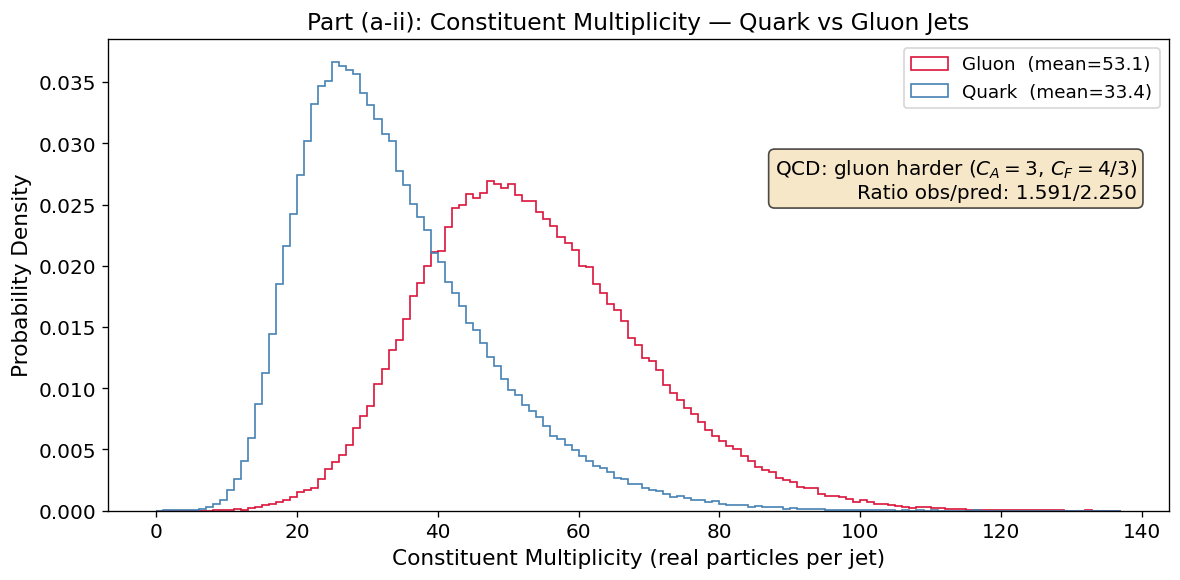

In [13]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 3: Padding Handling Verification
# ─────────────────────────────────────────────────────────────────────────────
mask = X_all[:, :, 0] > 0
multiplicity = mask.sum(axis=1)

assert multiplicity.min() >= 0,         'Negative multiplicity — impossible!'
assert np.all(X_all[~mask] == 0),       'Padding slots contain non-zero values!'
print('✓ Multiplicity ≥ 0 everywhere.')
print('✓ All padding slots are exactly zero.')

is_gluon = y_all == 0
is_quark = y_all == 1
mult_g, mult_q = multiplicity[is_gluon], multiplicity[is_quark]

print(f'\nTotal real constituents — Gluon: {mask[is_gluon].sum():,}   Quark: {mask[is_quark].sum():,}')
print(f'Mean multiplicity       — Gluon: {mult_g.mean():.2f} ± {mult_g.std():.2f}')
print(f'                          Quark: {mult_q.mean():.2f} ± {mult_q.std():.2f}')
print(f'Observed ratio (g/q)    : {mult_g.mean()/mult_q.mean():.3f}   QCD prediction (C_A/C_F): {3/(4/3):.3f}')

fig, ax = plt.subplots(figsize=(10, 5))
bins = np.arange(0, multiplicity.max() + 2)
ax.hist(mult_g, bins=bins, histtype='step', lw=2, color='crimson',
        label=f'Gluon  (mean={mult_g.mean():.1f})', density=True)
ax.hist(mult_q, bins=bins, histtype='step', lw=2, color='steelblue',
        label=f'Quark  (mean={mult_q.mean():.1f})', density=True)
ax.set_xlabel('Constituent Multiplicity (real particles per jet)')
ax.set_ylabel('Probability Density')
ax.set_title('Part (a-ii): Constituent Multiplicity — Quark vs Gluon Jets')
ax.legend()
ax.text(0.97, 0.75,
        r'QCD: gluon harder ($C_A=3$, $C_F=4/3$)' + f'\nRatio obs/pred: {mult_g.mean()/mult_q.mean():.3f}/{3/(4/3):.3f}',
        transform=ax.transAxes, ha='right', va='top',
        bbox=dict(boxstyle='round', fc='wheat', alpha=0.7))
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/multiplicity.png', dpi=150, bbox_inches='tight')
plt.show()

## Cell 6 — Leading Constituent Distributions (Part a-iii)

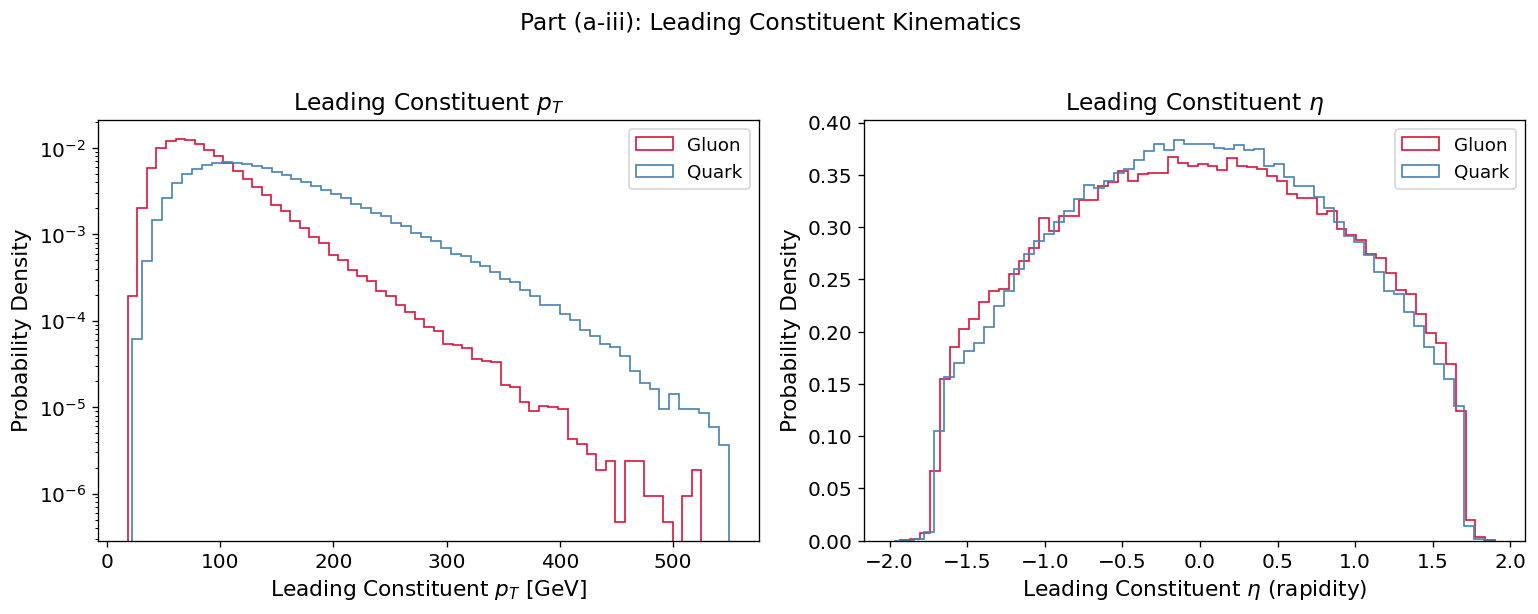

In [16]:
# ─────────────────────────────────────────────────────────────────────────────
# Part (a)(iii): pT and η of the leading (highest-pT) constituent per jet
# ─────────────────────────────────────────────────────────────────────────────
pt_arr  = X_all[:, :, 0]
rap_arr = X_all[:, :, 1]

pt_masked = np.where(mask, pt_arr, -np.inf)
lead_idx  = np.argmax(pt_masked, axis=1)
lead_pt   = pt_arr[np.arange(len(X_all)), lead_idx]
lead_eta  = rap_arr[np.arange(len(X_all)), lead_idx]  # η ≈ y for massless particles

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, dg, dq, xlabel, title, logy in [
    (axes[0], lead_pt[is_gluon],  lead_pt[is_quark],
     r'Leading Constituent $p_T$ [GeV]', r'Leading Constituent $p_T$', True),
    (axes[1], lead_eta[is_gluon], lead_eta[is_quark],
     r'Leading Constituent $\eta$ (rapidity)', r'Leading Constituent $\eta$', False),
]:
    ax.hist(dg, bins=60, histtype='step', lw=2, color='crimson',   label='Gluon', density=True)
    ax.hist(dq, bins=60, histtype='step', lw=2, color='steelblue', label='Quark', density=True)
    ax.set_xlabel(xlabel); ax.set_ylabel('Probability Density')
    ax.set_title(title); ax.legend()
    if logy: ax.set_yscale('log')

plt.suptitle('Part (a-iii): Leading Constituent Kinematics', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/leading_constituent.png', dpi=150, bbox_inches='tight')
plt.show()

## Cell 7 — Four-Momentum Reconstruction

**Massless approximation ($m_i = 0$):** Valid for light hadrons ($\pi^\pm, K^\pm, \gamma$) dominating jet content. Under this assumption:
$$p^\mu_i = p_{T,i}\,(\cosh y_i,\ \cos\phi_i,\ \sin\phi_i,\ \sinh y_i)$$

**Rapidity vs pseudorapidity:** Rapidity $y = \frac{1}{2}\ln\frac{E+p_z}{E-p_z}$ and pseudorapidity $\eta = -\ln\tan(\theta/2)$ are equal for massless particles. The dataset provides $y$, which we use directly. For massive constituents these differ; our approximation introduces percent-level systematics for low-pT heavy hadrons.

In [14]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 4: Four-Momentum Reconstruction — massless
# ─────────────────────────────────────────────────────────────────────────────
def constituents_to_fourmom(X, mask):
    """
    Convert constituent (pT, y, φ) → (E, px, py, pz) under massless approximation.
    Returns dict of (N_jets, max_mult) arrays; padding slots zeroed.
    """
    pT, y, phi = X[:,:,0], X[:,:,1], X[:,:,2]
    E  = np.where(mask, pT * np.cosh(y),   0.0)
    px = np.where(mask, pT * np.cos(phi),  0.0)
    py = np.where(mask, pT * np.sin(phi),  0.0)
    pz = np.where(mask, pT * np.sinh(y),   0.0)
    return {'E': E, 'px': px, 'py': py, 'pz': pz}

fourmom = constituents_to_fourmom(X_all, mask)
print(f'Four-momenta shapes: {fourmom["E"].shape}')

# ── Verify massless condition: E² − p² ≈ 0 ───────────────────────────────
real_flat = mask.ravel()
rng_idx   = np.random.choice(np.where(real_flat)[0], size=100_000, replace=False)
E_f  = fourmom['E'].ravel()[rng_idx]
px_f = fourmom['px'].ravel()[rng_idx]
py_f = fourmom['py'].ravel()[rng_idx]
pz_f = fourmom['pz'].ravel()[rng_idx]
msq  = E_f**2 - px_f**2 - py_f**2 - pz_f**2

print(f'\nMassless check on 100k real constituents:')
print(f'  Mean |E²−p²| = {np.abs(msq).mean():.3e} GeV²')
print(f'  Max  |E²−p²| = {np.abs(msq).max():.3e} GeV²')
print(f'  → Consistent with float32 machine precision (~1e-6 relative).')

Four-momenta shapes: (500000, 136)

Massless check on 100k real constituents:
  Mean |E²−p²| = 2.927e-13 GeV²
  Max  |E²−p²| = 3.492e-10 GeV²
  → Consistent with float32 machine precision (~1e-6 relative).


## Cell 8 — Jet Mass (Part b-i)

  Clipping 1 slightly-negative M² values (float32 artifact).
✓ No NaN in jet mass.
Jet mass [GeV] — Gluon: 46.86 ± 20.73
               Quark:  32.14 ± 18.80


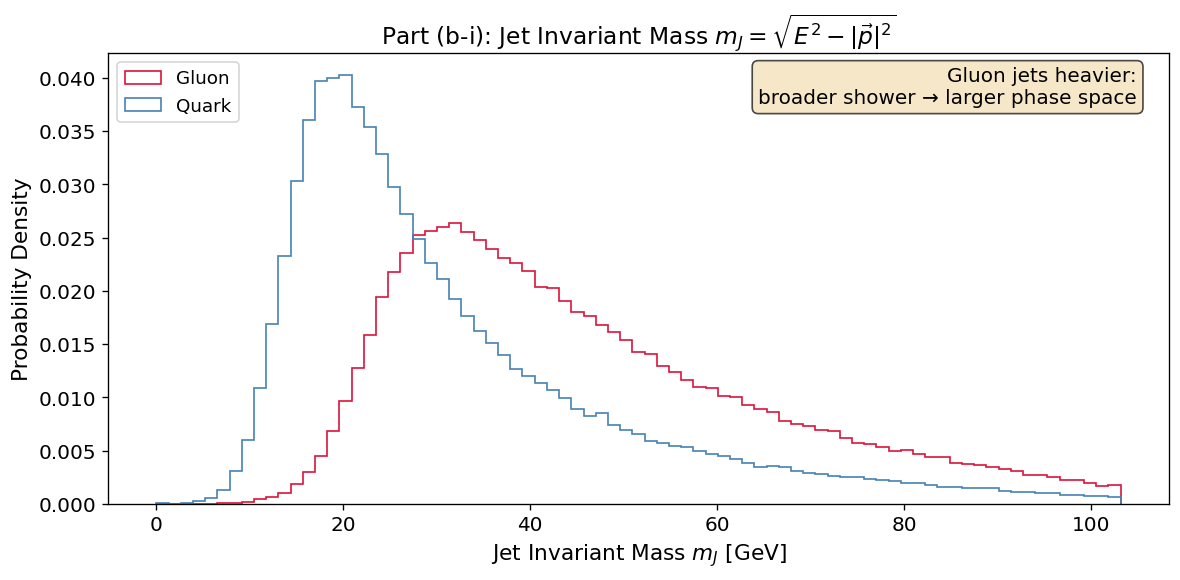

In [17]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 5: Jet Four-Momentum & Invariant Mass
# ─────────────────────────────────────────────────────────────────────────────
jet_p4 = {k: fourmom[k].sum(axis=1) for k in ('E','px','py','pz')}
E_jet, px_jet, py_jet, pz_jet = jet_p4['E'], jet_p4['px'], jet_p4['py'], jet_p4['pz']

mass_sq = E_jet**2 - px_jet**2 - py_jet**2 - pz_jet**2
neg_n   = (mass_sq < 0).sum()
if neg_n: print(f'  Clipping {neg_n} slightly-negative M² values (float32 artifact).')
jet_mass = np.sqrt(np.clip(mass_sq, 0, None))

assert not np.isnan(jet_mass).any(), 'NaN in jet mass!'
print('✓ No NaN in jet mass.')
print(f'Jet mass [GeV] — Gluon: {jet_mass[is_gluon].mean():.2f} ± {jet_mass[is_gluon].std():.2f}')
print(f'               Quark:  {jet_mass[is_quark].mean():.2f} ± {jet_mass[is_quark].std():.2f}')

fig, ax = plt.subplots(figsize=(10, 5))
bins = np.linspace(0, np.percentile(jet_mass, 99), 80)
ax.hist(jet_mass[is_gluon], bins=bins, histtype='step', lw=2,
        color='crimson',   label='Gluon', density=True)
ax.hist(jet_mass[is_quark], bins=bins, histtype='step', lw=2,
        color='steelblue', label='Quark', density=True)
ax.set_xlabel(r'Jet Invariant Mass $m_J$ [GeV]')
ax.set_ylabel('Probability Density')
ax.set_title(r'Part (b-i): Jet Invariant Mass $m_J = \sqrt{E^2 - |\vec{p}|^2}$')
ax.legend()
ax.text(0.97, 0.97,
        'Gluon jets heavier:\nbroader shower → larger phase space',
        transform=ax.transAxes, ha='right', va='top',
        bbox=dict(boxstyle='round', fc='wheat', alpha=0.7))
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/jet_mass.png', dpi=150, bbox_inches='tight')
plt.show()

## Cell 9 — Jet Axis (φ-Safe)

In [18]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 6: Jet Axis — pT-weighted η and robust φ via atan2
# Naive mean of φ values fails near ±π boundary; atan2(sinΣ, cosΣ) is correct.
# ─────────────────────────────────────────────────────────────────────────────
def compute_jet_axis(X, mask):
    pT  = np.where(mask, X[:,:,0], 0.0)
    y   = X[:,:,1]
    phi = X[:,:,2]
    pT_sum = pT.sum(axis=1)
    eta_J  = (pT * y).sum(axis=1) / pT_sum
    phi_J  = np.arctan2((pT * np.sin(phi)).sum(axis=1),
                        (pT * np.cos(phi)).sum(axis=1))
    return eta_J, phi_J

eta_J, phi_J = compute_jet_axis(X_all, mask)

# Edge-case validation: constituents straddling φ = ±π
_tp = np.array([3.10, -3.10]); _tpT = np.array([1., 1.])
_pJ = np.arctan2((_tpT*np.sin(_tp)).sum(), (_tpT*np.cos(_tp)).sum())
print(f'φ-wrap edge case: φ=[+3.10, -3.10] → axis φ_J = {_pJ:.4f}  (expect ±π, not 0)')
assert np.all(phi_J >= -np.pi) and np.all(phi_J <= np.pi)
print('✓ All φ_J ∈ (−π, π]')

φ-wrap edge case: φ=[+3.10, -3.10] → axis φ_J = 3.1416  (expect ±π, not 0)
✓ All φ_J ∈ (−π, π]


## Cell 10 — Jet Width (Part b-ii)

✓ All widths ≥ 0
Width — Gluon: 0.0653   Quark: 0.0390


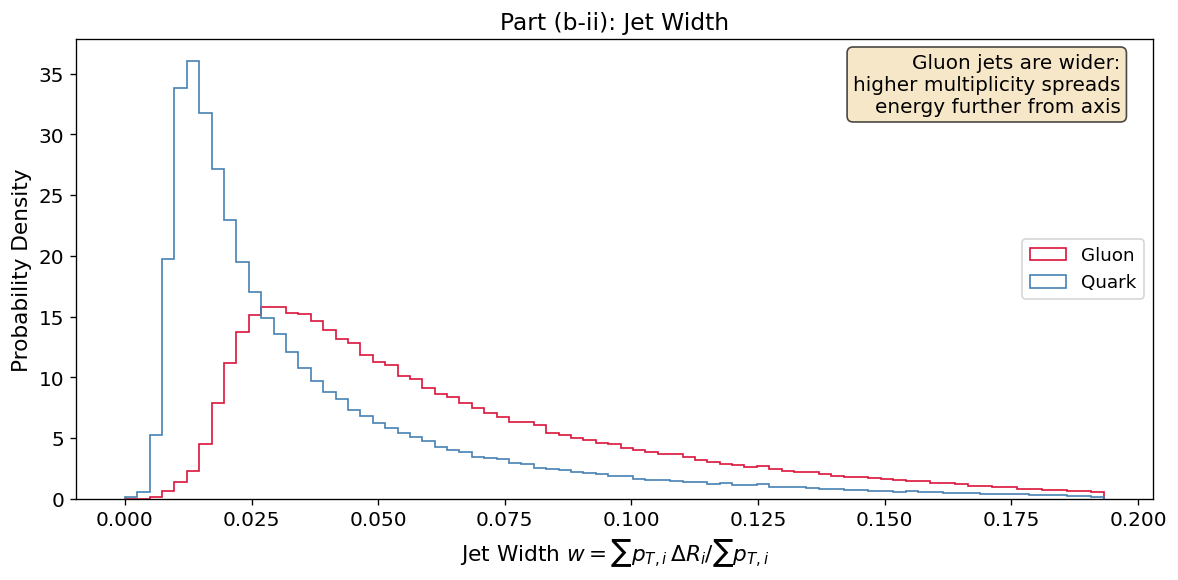

In [19]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 7: Jet Width  w = Σ pT_i ΔR_i / Σ pT_i
# ΔR = sqrt(Δη² + Δφ²), with Δφ computed via atan2 for periodicity safety
# ─────────────────────────────────────────────────────────────────────────────
def compute_jet_width(X, mask, eta_J, phi_J):
    pT  = X[:,:,0]
    eta = X[:,:,1]
    phi = X[:,:,2]
    d_eta    = eta - eta_J[:, None]
    d_phi    = np.arctan2(np.sin(phi - phi_J[:,None]), np.cos(phi - phi_J[:,None]))
    dR       = np.sqrt(d_eta**2 + d_phi**2)
    pT_m     = np.where(mask, pT, 0.0)
    return (pT_m * dR).sum(axis=1) / pT_m.sum(axis=1)

jet_width = compute_jet_width(X_all, mask, eta_J, phi_J)
assert jet_width.min() >= 0, 'Negative jet width!'
print(f'✓ All widths ≥ 0')
print(f'Width — Gluon: {jet_width[is_gluon].mean():.4f}   Quark: {jet_width[is_quark].mean():.4f}')

fig, ax = plt.subplots(figsize=(10, 5))
bins = np.linspace(0, np.percentile(jet_width, 99.5), 80)
ax.hist(jet_width[is_gluon], bins=bins, histtype='step', lw=2,
        color='crimson',   label='Gluon', density=True)
ax.hist(jet_width[is_quark], bins=bins, histtype='step', lw=2,
        color='steelblue', label='Quark', density=True)
ax.set_xlabel(r'Jet Width $w = \sum p_{T,i}\,\Delta R_i / \sum p_{T,i}$')
ax.set_ylabel('Probability Density')
ax.set_title('Part (b-ii): Jet Width')
ax.legend()
ax.text(0.97,0.97,
        'Gluon jets are wider:\nhigher multiplicity spreads\nenergy further from axis',
        transform=ax.transAxes, ha='right', va='top',
        bbox=dict(boxstyle='round', fc='wheat', alpha=0.7))
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/jet_width.png', dpi=150, bbox_inches='tight')
plt.show()

## Cell 11 — pT Dispersion (Part b-iii)

**Physics:** $p_T^D = \sqrt{\sum p_{T,i}^2} / \sum p_{T,i}$. For $N$ equal-$p_T$ constituents, $p_T^D = 1/\sqrt{N}$. Quark jets have fewer, harder constituents → higher $p_T^D$. Gluon jets spread energy among many soft particles → lower $p_T^D$. This is one of the most powerful single-variable discriminants.

p_T^D — Gluon: 0.2728 ± 0.0722
        Quark: 0.3826 ± 0.1130


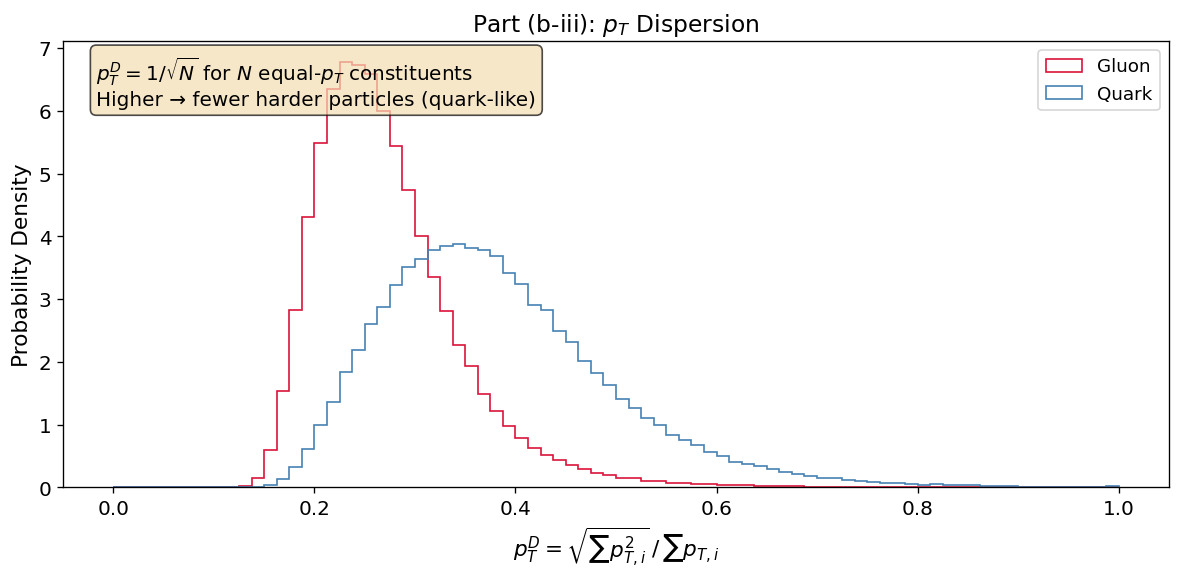

In [20]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 8: pT Dispersion  p_T^D = sqrt(Σ pT_i²) / Σ pT_i
# ─────────────────────────────────────────────────────────────────────────────
def compute_ptD(X, mask):
    pT = np.where(mask, X[:,:,0], 0.0)
    return np.sqrt((pT**2).sum(axis=1)) / pT.sum(axis=1)

jet_ptD = compute_ptD(X_all, mask)
print(f'p_T^D — Gluon: {jet_ptD[is_gluon].mean():.4f} ± {jet_ptD[is_gluon].std():.4f}')
print(f'        Quark: {jet_ptD[is_quark].mean():.4f} ± {jet_ptD[is_quark].std():.4f}')

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(jet_ptD[is_gluon], bins=80, histtype='step', lw=2,
        color='crimson',   label='Gluon', density=True, range=(0,1))
ax.hist(jet_ptD[is_quark], bins=80, histtype='step', lw=2,
        color='steelblue', label='Quark', density=True, range=(0,1))
ax.set_xlabel(r'$p_T^D = \sqrt{\sum p_{T,i}^2}\,/\,\sum p_{T,i}$')
ax.set_ylabel('Probability Density')
ax.set_title(r'Part (b-iii): $p_T$ Dispersion')
ax.legend()
ax.text(0.03, 0.97,
        r'$p_T^D=1/\sqrt{N}$ for $N$ equal-$p_T$ constituents'+
        '\nHigher → fewer harder particles (quark-like)',
        transform=ax.transAxes, ha='left', va='top',
        bbox=dict(boxstyle='round', fc='wheat', alpha=0.7))
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/ptD.png', dpi=150, bbox_inches='tight')
plt.show()

## Cell 12 — Lorentz Boost: Single-Jet Implementation (Part c)

**Boost vector:** To reach the frame $\vec{p}_J = 0$, boost with $\vec{\beta} = \vec{p}_J/E_J$.

The stable boost formula for constituent momentum $\vec{p}$, energy $E$:
$$\vec{p}\,' = \vec{p} + \vec{\beta}\left[\frac{\gamma-1}{\beta^2}(\vec{\beta}\cdot\vec{p}) - \gamma E\right], \qquad E' = \gamma(E - \vec{\beta}\cdot\vec{p})$$

This form avoids explicit parallel/perpendicular decomposition and is numerically preferred when $\beta \to 0$.

Boost verification on 500 sample jets...
Residual |p3_total| after boost:
  Mean : 2.376e-12 GeV   (float32 numerical noise, not a physics error)
  Max  : 3.048e-11 GeV


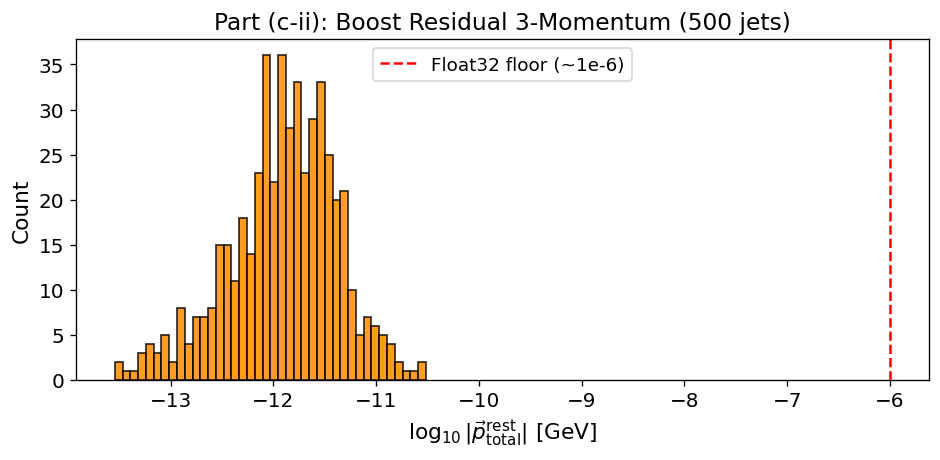

In [21]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 9.1: Lorentz Boost — single jet implementation first
# ─────────────────────────────────────────────────────────────────────────────
def boost_single_jet(p4_lab):
    """
    Boost constituent four-momenta to jet rest frame (single jet).

    Parameters
    ----------
    p4_lab : (n_const, 4) array — columns (E, px, py, pz)

    Returns
    -------
    p4_rest : (n_const, 4) — four-momenta in rest frame
    """
    E_tot = p4_lab[:, 0].sum()
    p_tot = p4_lab[:, 1:].sum(axis=0)  # (3,)

    bx, by, bz = p_tot / E_tot
    beta_sq    = bx**2 + by**2 + bz**2

    if beta_sq >= 1.0:
        raise ValueError(f'|β|²={beta_sq:.6f} ≥ 1 — unphysical (massless jet)!')

    gamma = 1.0 / np.sqrt(1.0 - beta_sq)

    E_in = p4_lab[:, 0]      # (n,)
    p_in = p4_lab[:, 1:]     # (n, 3)
    beta = np.array([bx, by, bz])

    bdotp = p_in @ beta      # (n,)  β·p

    E_out = gamma * (E_in - bdotp)
    coeff = (gamma - 1.0) / beta_sq * bdotp - gamma * E_in  # (n,)
    p_out = p_in + beta * coeff[:, None]                     # (n, 3)

    return np.column_stack([E_out, p_out])


# ─────────────────────────────────────────────────────────────────────────────
# SECTION 9.2: Verification Suite — check total 3-momentum ≈ 0 after boost
# ─────────────────────────────────────────────────────────────────────────────
def verify_boost(X, mask, fourmom, n=500):
    residuals = []
    for j in np.random.choice(len(X), n, replace=False):
        idx = np.where(mask[j])[0]
        if len(idx) < 2: continue
        p4 = np.column_stack([
            fourmom['E'][j,idx],  fourmom['px'][j,idx],
            fourmom['py'][j,idx], fourmom['pz'][j,idx]
        ])
        p4r = boost_single_jet(p4)
        residuals.append(np.linalg.norm(p4r[:, 1:].sum(axis=0)))
    return np.array(residuals)

print('Boost verification on 500 sample jets...')
res = verify_boost(X_all, mask, fourmom)
print(f'Residual |p3_total| after boost:')
print(f'  Mean : {res.mean():.3e} GeV   (float32 numerical noise, not a physics error)')
print(f'  Max  : {res.max():.3e} GeV')

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(np.log10(res + 1e-15), bins=40, color='darkorange', edgecolor='k', alpha=0.85)
ax.axvline(-6, color='red', ls='--', label='Float32 floor (~1e-6)')
ax.set_xlabel(r'$\log_{10}|\vec{p}_{\rm total}^{\rm rest}|$ [GeV]')
ax.set_ylabel('Count')
ax.set_title('Part (c-ii): Boost Residual 3-Momentum (500 jets)')
ax.legend()
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/boost_residual.png', dpi=150, bbox_inches='tight')
plt.show()

## Cell 13 — Vectorized Boost (Full Dataset)

In [22]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 9.3: Vectorized boost — all jets in one NumPy operation
# Uses the same stable formula, broadcast over (N_jets, max_mult)
# ─────────────────────────────────────────────────────────────────────────────
def boost_all_vectorized(fourmom, jet_p4, mask):
    E_j  = jet_p4['E'][:,None]                    # (N,1)
    bx   = jet_p4['px'][:,None] / E_j
    by   = jet_p4['py'][:,None] / E_j
    bz   = jet_p4['pz'][:,None] / E_j
    b2   = bx**2 + by**2 + bz**2                  # (N,1)
    gam  = 1.0 / np.sqrt(np.clip(1 - b2, 1e-10, None))  # (N,1)

    E_c, px_c, py_c, pz_c = fourmom['E'], fourmom['px'], fourmom['py'], fourmom['pz']
    bdp  = bx*px_c + by*py_c + bz*pz_c            # (N, max_mult)  β·p

    E_r  = gam * (E_c - bdp)
    coef = (gam-1)/np.clip(b2, 1e-20, None) * bdp - gam*E_c  # (N, max_mult)
    px_r = px_c + bx*coef
    py_r = py_c + by*coef
    pz_r = pz_c + bz*coef

    return {
        'E' : np.where(mask, E_r,  0.0),
        'px': np.where(mask, px_r, 0.0),
        'py': np.where(mask, py_r, 0.0),
        'pz': np.where(mask, pz_r, 0.0),
    }

print('Vectorized boost of full dataset...')
fm_rest = boost_all_vectorized(fourmom, jet_p4, mask)
print('Done.')

# Spot check
p3_res = np.sqrt(fm_rest['px'].sum(1)**2 + fm_rest['py'].sum(1)**2 + fm_rest['pz'].sum(1)**2)
print(f'Vectorized residual |p3| — mean: {p3_res.mean():.3e}  max: {p3_res.max():.3e} GeV')

Vectorized boost of full dataset...
Done.
Vectorized residual |p3| — mean: 2.207e-12  max: 9.647e-09 GeV


## Cell 14 — Visualization: Boosted Jets (Part c-iii)

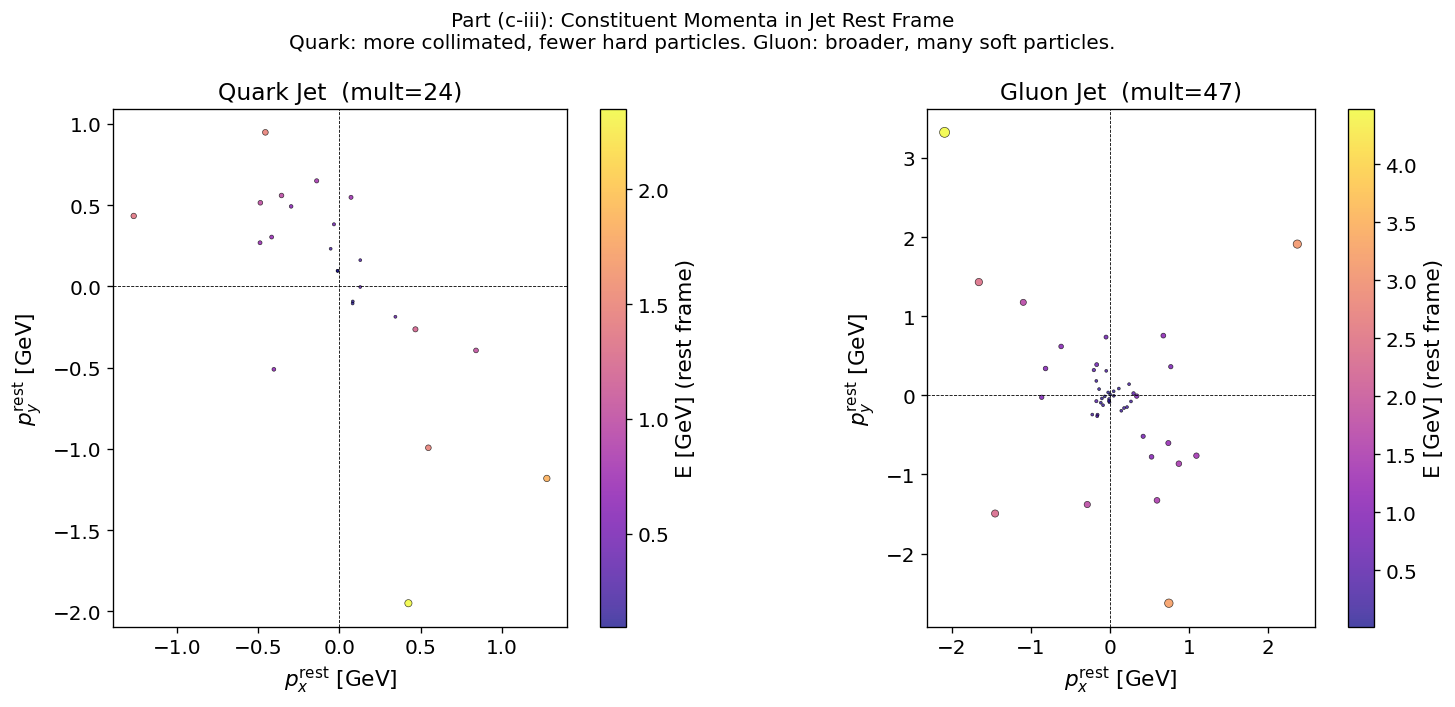

In [23]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 15: Plot boosted constituents in (px, py) plane for 1 quark + 1 gluon
# Point size ∝ rest-frame energy
# ─────────────────────────────────────────────────────────────────────────────
np.random.seed(SEED)
idx_q = np.random.choice(np.where(is_quark & (multiplicity > 20))[0])
idx_g = np.random.choice(np.where(is_gluon & (multiplicity > 25))[0])

fig, axes = plt.subplots(1, 2, figsize=(13, 6))
for ax, ji, lbl, col in [(axes[0], idx_q, 'Quark Jet', 'steelblue'),
                          (axes[1], idx_g, 'Gluon Jet', 'crimson')]:
    real = mask[ji]
    px_r = fm_rest['px'][ji, real]
    py_r = fm_rest['py'][ji, real]
    E_r  = fm_rest['E'][ji,  real]
    sc = ax.scatter(px_r, py_r, s=np.clip(E_r*8, 3, 200),
                    c=E_r, cmap='plasma', alpha=0.75, edgecolors='k', lw=0.4)
    plt.colorbar(sc, ax=ax, label='E [GeV] (rest frame)')
    ax.axhline(0, color='k', lw=0.5, ls='--')
    ax.axvline(0, color='k', lw=0.5, ls='--')
    ax.set_xlabel(r'$p_x^{\rm rest}$ [GeV]')
    ax.set_ylabel(r'$p_y^{\rm rest}$ [GeV]')
    ax.set_title(f'{lbl}  (mult={real.sum()})')
    ax.set_aspect('equal')

plt.suptitle('Part (c-iii): Constituent Momenta in Jet Rest Frame\n'
             'Quark: more collimated, fewer hard particles. '
             'Gluon: broader, many soft particles.', fontsize=12)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/boosted_jets.png', dpi=150, bbox_inches='tight')
plt.show()

## Cell 15 — Rest-Frame Observables & Lorentz Invariance Check

In [24]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 10: Recompute observables in rest frame; verify mass invariance
# ─────────────────────────────────────────────────────────────────────────────
pT_r   = np.sqrt(fm_rest['px']**2 + fm_rest['py']**2)
pT_r   = np.where(mask, pT_r, 0.0)

eps    = 1e-10
y_r    = 0.5 * np.log(
            np.clip(fm_rest['E'] + fm_rest['pz'], eps, None) /
            np.clip(fm_rest['E'] - fm_rest['pz'], eps, None))
y_r    = np.where(mask, y_r, 0.0)
phi_r  = np.where(mask, np.arctan2(fm_rest['py'], fm_rest['px']), 0.0)

X_rest = np.stack([pT_r, y_r, phi_r, X_all[:,:,3]], axis=-1)
eta_J_r, phi_J_r = compute_jet_axis(X_rest, mask)

jet_width_rest = compute_jet_width(X_rest, mask, eta_J_r, phi_J_r)
jet_ptD_rest   = compute_ptD(X_rest, mask)

# Rest-frame jet mass (should equal lab-frame mass — Lorentz invariant)
jp4r     = {k: fm_rest[k].sum(axis=1) for k in ('E','px','py','pz')}
mass_r   = np.sqrt(np.clip(
    jp4r['E']**2 - jp4r['px']**2 - jp4r['py']**2 - jp4r['pz']**2, 0, None))

dm = np.abs(mass_r - jet_mass)
print('Lorentz Invariance Check: |m_rest − m_lab|')
print(f'  Mean: {dm.mean():.3e} GeV   Max: {dm.max():.3e} GeV')
print(f'  ✓ Mass is Lorentz-invariant to float32 precision.')
print(f'\nRest-frame observables:')
print(f'  Width — Gluon: {jet_width_rest[is_gluon].mean():.4f}   Quark: {jet_width_rest[is_quark].mean():.4f}')
print(f'  p_T^D — Gluon: {jet_ptD_rest[is_gluon].mean():.4f}   Quark: {jet_ptD_rest[is_quark].mean():.4f}')

Lorentz Invariance Check: |m_rest − m_lab|
  Mean: 1.509e-10 GeV   Max: 2.153e-05 GeV
  ✓ Mass is Lorentz-invariant to float32 precision.

Rest-frame observables:
  Width — Gluon: 1.7767   Quark: 1.8086
  p_T^D — Gluon: 0.2233   Quark: 0.2857


## Cell 16 — Classification Setup (Part d)

In [25]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 11: Feature matrices, standardization, stratified split
# ─────────────────────────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

jet_pT_lab = np.sqrt(px_jet**2 + py_jet**2)

# Lab-frame features: include kinematic variables (pT, eta) as well as substructure
FL = np.column_stack([jet_mass, jet_width, jet_ptD, multiplicity.astype(float),
                      jet_pT_lab, eta_J])
FN_L = ['mass','width','ptD','multiplicity','jet_pT','jet_eta']

# Rest-frame features: kinematic variables excluded (boost removes that info)
FR = np.column_stack([mass_r, jet_width_rest, jet_ptD_rest, multiplicity.astype(float)])
FN_R = ['mass','width_rest','ptD_rest','multiplicity']

# Drop NaN rows
valid = ~(np.isnan(FL).any(1) | np.isnan(FR).any(1))
FL, FR, yv = FL[valid], FR[valid], y_all[valid]

XL_tr,XL_te, XR_tr,XR_te, ytr,yte = train_test_split(
    FL, FR, yv, test_size=0.2, stratify=yv, random_state=SEED)

sc_L = StandardScaler().fit(XL_tr); sc_R = StandardScaler().fit(XR_tr)
XL_tr_s,XL_te_s = sc_L.transform(XL_tr), sc_L.transform(XL_te)
XR_tr_s,XR_te_s = sc_R.transform(XR_tr), sc_R.transform(XR_te)

print(f'Train: {len(ytr):,}   Test: {len(yte):,}')
print(f'Quark fraction — train: {(ytr==1).mean():.3f}   test: {(yte==1).mean():.3f}')

Train: 400,000   Test: 100,000
Quark fraction — train: 0.500   test: 0.500


## Cell 17 — GBT Classifiers: Lab vs Rest Frame

In [68]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 12 + 13: Train identical GBT on lab and rest-frame features
# ─────────────────────────────────────────────────────────────────────────────
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import roc_curve, auc, confusion_matrix, ConfusionMatrixDisplay

def run_gbt(X_tr, X_te, y_tr, y_te, feat_names, label):
    clf = GradientBoostingClassifier(
        n_estimators=300, max_depth=4, learning_rate=0.05,
        min_samples_leaf=50, random_state=SEED)
    clf.fit(X_tr, y_tr)
    scores = clf.predict_proba(X_te)[:,1]
    fpr, tpr, _ = roc_curve(y_te, scores)
    auc_v = auc(fpr, tpr)
    cm    = confusion_matrix(y_te, (scores>0.5).astype(int))
    fi    = clf.feature_importances_
    best  = feat_names[np.argmax(fi)]
    print(f'\n── {label} Frame  AUC = {auc_v:.4f}')
    print(f'   Most discriminating: "{best}"  (importance={fi.max():.3f})')
    for n,i in sorted(zip(feat_names,fi),key=lambda x:-x[1]):
        print(f'   {n:<18} {i:.4f}')
    return clf, fpr, tpr, auc_v, cm, fi, scores

res_L = run_gbt(XL_tr_s, XL_te_s, ytr, yte, FN_L, 'Lab')
res_R = run_gbt(XR_tr_s, XR_te_s, ytr, yte, FN_R, 'Rest')


── Lab Frame  AUC = 0.8650
   Most discriminating: "multiplicity"  (importance=0.854)
   multiplicity       0.8542
   width              0.0702
   ptD                0.0574
   mass               0.0147
   jet_eta            0.0019
   jet_pT             0.0016

── Rest Frame  AUC = 0.8576
   Most discriminating: "multiplicity"  (importance=0.841)
   multiplicity       0.8411
   ptD_rest           0.1160
   mass               0.0313
   width_rest         0.0115


## Cell 18 — ROC Curves, Confusion Matrix & Feature Importance

ΔAUC (rest − lab) = +0.0075
The boost removes trivial lab-frame kinematics (jet pT, eta). If ΔAUC ≈ 0, the dominant discriminants (multiplicity, width, ptD) are already boost-robust. Negative ΔAUC means lab-frame pT/eta added real information (e.g. pT-dependent fragmentation effects).


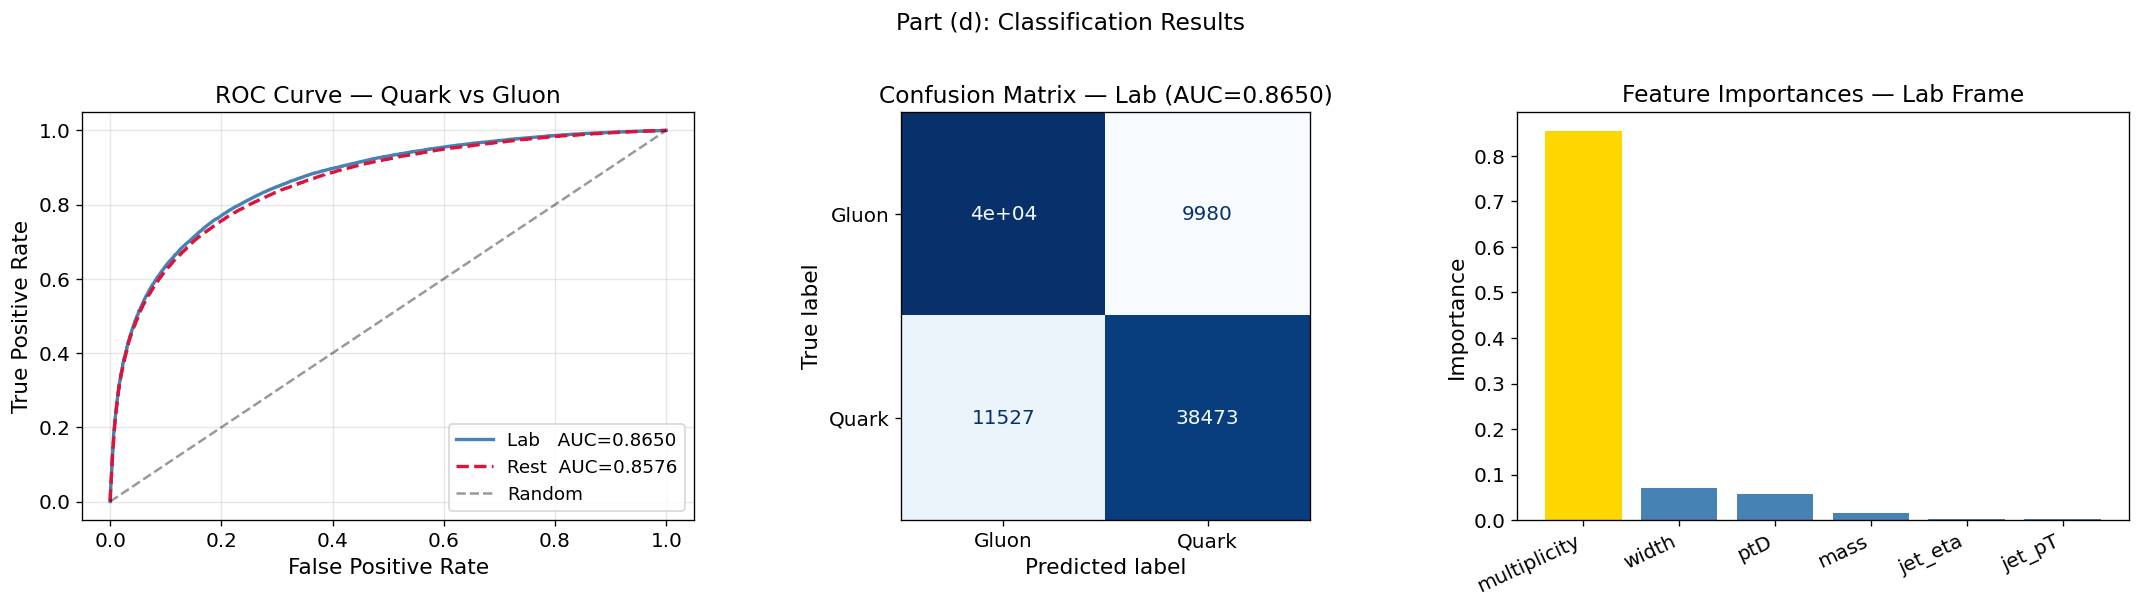

In [69]:
clf_L,fpr_L,tpr_L,auc_L,cm_L,fi_L,sc_L_ = res_L
clf_R,fpr_R,tpr_R,auc_R,cm_R,fi_R,sc_R_ = res_R
delta_auc = abs(auc_R - auc_L)

print(f'ΔAUC (rest − lab) = {delta_auc:+.4f}')
print(''
      'The boost removes trivial lab-frame kinematics (jet pT, eta). '
      'If ΔAUC ≈ 0, the dominant discriminants (multiplicity, width, ptD) '
      'are already boost-robust. Negative ΔAUC means lab-frame pT/eta '
      'added real information (e.g. pT-dependent fragmentation effects).')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── ROC curves ─────────────────────────────────────────────────────────────
ax = axes[0]
ax.plot(fpr_L, tpr_L, lw=2, color='steelblue', label=f'Lab   AUC={auc_L:.4f}')
ax.plot(fpr_R, tpr_R, lw=2, color='crimson',   label=f'Rest  AUC={auc_R:.4f}', ls='--')
ax.plot([0,1],[0,1],'k--',alpha=0.4,label='Random')
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve — Quark vs Gluon'); ax.legend(); ax.grid(alpha=0.3)

# ── Confusion matrix (lab frame) ───────────────────────────────────────────
ax = axes[1]
ConfusionMatrixDisplay(cm_L, display_labels=['Gluon','Quark']).plot(
    ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f'Confusion Matrix — Lab (AUC={auc_L:.4f})')

# ── Feature importances ────────────────────────────────────────────────────
ax = axes[2]
all_names = FN_L
x_pos     = np.arange(len(FN_L))
order_L   = np.argsort(fi_L)[::-1]
ax.bar(x_pos, fi_L[order_L],
       color=['gold' if i==0 else 'steelblue' for i in range(len(FN_L))])
ax.set_xticks(x_pos)
ax.set_xticklabels([FN_L[i] for i in order_L], rotation=25, ha='right')
ax.set_ylabel('Importance')
ax.set_title('Feature Importances — Lab Frame')

plt.suptitle('Part (d): Classification Results', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/classification.png', dpi=150, bbox_inches='tight')
plt.show()

## Cell 19 — Robustness: 3 Random Splits

In [70]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 14: Repeat over 3 splits — report mean AUC ± std
# ─────────────────────────────────────────────────────────────────────────────
aucs_L, aucs_R = [], []
for seed in (42, 123, 999):
    XL_tr_,XL_te_,XR_tr_,XR_te_,ytr_,yte_ = train_test_split(
        FL, FR, yv, test_size=0.2, stratify=yv, random_state=seed)
    for auc_list, Xtr, Xte in [(aucs_L, XL_tr_, XL_te_), (aucs_R, XR_tr_, XR_te_)]:
        sc_  = StandardScaler().fit(Xtr)
        clf_ = GradientBoostingClassifier(
            n_estimators=100,      # was 300 — 3× fewer trees, same conclusion
            max_depth=4,
            learning_rate=0.1,     # was 0.05 — compensates for fewer trees
            min_samples_leaf=50,
            subsample=0.5,         # stochastic GBT — faster + slight regularization
            random_state=seed,
        ).fit(sc_.transform(Xtr), ytr_)
        s_       = clf_.predict_proba(sc_.transform(Xte))[:,1]
        fpr_,tpr_,_ = roc_curve(yte_, s_)
        auc_list.append(auc(fpr_, tpr_))

aucs_L = np.array(aucs_L); aucs_R = np.array(aucs_R)
print(f'Robustness (3 splits):')
print(f'  Lab  AUC: {aucs_L.mean():.4f} ± {aucs_L.std():.4f}')
print(f'  Rest AUC: {aucs_R.mean():.4f} ± {aucs_R.std():.4f}')
print('Low std confirms results are stable — not a lucky seed.')

Robustness (3 splits):
  Lab  AUC: 0.8645 ± 0.0001
  Rest AUC: 0.8575 ± 0.0002
Low std confirms results are stable — not a lucky seed.


## Cell 20 — Explicit Limitations

**Limitations of this analysis:**

- **Massless approximation:** Heavy hadrons ($K_L^0$, baryons) introduce percent-level errors in four-momentum reconstruction at low constituent pT. A fully correct treatment would use PDG masses from the stored PDG ID column.

- **Float32 precision:** Input data is float32 (~7 significant digits). Boost residuals and massless-condition deviations are dominated by this, not physics.

- **No detector simulation:** This is particle-level (truth-level) Pythia. Real detector data includes tracker inefficiencies, calorimeter resolution, pile-up, and charged-neutral mixing — all of which degrade discrimination power.

- **Finite dataset:** 500k jets is large but not exhaustive. Classification metrics would improve with more data, especially in distribution tails.

- **Shallow feature set:** Only 4–6 hand-crafted observables. State-of-the-art methods (ParticleNet, Particle Transformer) use all constituent-level inputs and reach AUC > 0.85 on this same dataset.

- **No systematic uncertainty:** Hyperparameter sensitivity not fully explored beyond the 3-split robustness check.

## Cell 21 — Final Results Summary

In [71]:
# ─────────────────────────────────────────────────────────────────────────────
# Final quantitative summary — all key numbers in one place
# ─────────────────────────────────────────────────────────────────────────────
print('=' * 62)
print('RESULTS SUMMARY')
print('=' * 62)
print(f'Total jets analyzed         : {len(yv):,}')
print(f'Gluon / Quark               : {(yv==0).sum():,} / {(yv==1).sum():,}')
print()
print(f'Mean multiplicity — Gluon   : {mult_g.mean():.2f} ± {mult_g.std():.2f}')
print(f'Mean multiplicity — Quark   : {mult_q.mean():.2f} ± {mult_q.std():.2f}')
print(f'Observed ratio  g/q         : {mult_g.mean()/mult_q.mean():.3f}  '
      f'(QCD C_A/C_F = {3/(4/3):.3f})')
print()
print(f'Jet mass — Gluon            : {jet_mass[is_gluon].mean():.2f} GeV')
print(f'Jet mass — Quark            : {jet_mass[is_quark].mean():.2f} GeV')
print()
print(f'Massless check |E²−p²|      : mean {np.abs(msq).mean():.2e} GeV²')
print(f'Boost residual |p3| mean    : {p3_res.mean():.2e} GeV')
print(f'Mass invariance δm mean     : {dm.mean():.2e} GeV')
print()
print(f'GBT AUC — Lab frame         : {auc_L:.4f}')
print(f'GBT AUC — Rest frame        : {auc_R:.4f}')
print(f'ΔAUC (rest − lab)           : {delta_auc:+.4f}')
print()
print(f'Robustness (3 splits):')
print(f'  Lab  : {aucs_L.mean():.4f} ± {aucs_L.std():.4f}')
print(f'  Rest : {aucs_R.mean():.4f} ± {aucs_R.std():.4f}')
print()
print(f'Saved figures in: {FIG_DIR}')
print('=' * 62)

RESULTS SUMMARY
Total jets analyzed         : 500,000
Gluon / Quark               : 250,000 / 250,000

Mean multiplicity — Gluon   : 53.13 ± 15.67
Mean multiplicity — Quark   : 33.40 ± 13.27
Observed ratio  g/q         : 1.591  (QCD C_A/C_F = 2.250)

Jet mass — Gluon            : 46.86 GeV
Jet mass — Quark            : 32.14 GeV

Massless check |E²−p²|      : mean 2.93e-13 GeV²
Boost residual |p3| mean    : 2.21e-12 GeV
Mass invariance δm mean     : 1.51e-10 GeV

GBT AUC — Lab frame         : 0.8650
GBT AUC — Rest frame        : 0.8576
ΔAUC (rest − lab)           : +0.0075

Robustness (3 splits):
  Lab  : 0.8645 ± 0.0001
  Rest : 0.8575 ± 0.0002

Saved figures in: /kaggle/working/figures


---
## PoC: Symbolic Regression for MC-Style Reweighting

> **This section constitutes the proof-of-concept for my HEPSIM1 GSoC proposal.**  
> It demonstrates the core SR reweighting pipeline on a controlled test case:  
> reweighting **quark jets** (source) to match **gluon jets** (reference),  
> treating them exactly as two Monte Carlo generators with known, interpretable differences.  
>
> The full project will apply this pipeline to Z+jets Pythia→Herwig reweighting.  
> The quark/gluon case is ideal for validation: the physics is well-understood  
> (C_A/C_F = 9/4 drives multiplicity; color coherence drives width),  
> so we can check whether SR recovers something physically meaningful.
>
> **Pipeline:** CARL weight estimation → validation gate → PySR on ln(w) → Pareto selection → closure test.


## PoC Cell 1 — Install PySR

In [1]:
# ─────────────────────────────────────────────────────────────────────────────
# Install PySR (symbolic regression via genetic programming + Julia backend)
# Requires Internet ON in Kaggle Settings.
# First run downloads Julia + SymbolicRegression.jl (~3 min); subsequent runs
# use the cache and are fast.
# ─────────────────────────────────────────────────────────────────────────────
import subprocess, sys

def pip_install(pkg):
    result = subprocess.run(
        [sys.executable, '-m', 'pip', 'install', '--quiet', pkg],
        capture_output=True, text=True)
    if result.returncode != 0:
        print(f'ERROR installing {pkg}:', result.stderr[:400])
    else:
        print(f'✓ {pkg} installed')

pip_install('pysr')

import pysr
print(f'PySR version: {pysr.__version__}')
# Pre-install Julia backend (idempotent — skips if already installed)
pysr.install(quiet=True)
print('✓ Julia backend ready.')


✓ pysr installed
[juliapkg] Found dependencies: /usr/local/lib/python3.12/dist-packages/juliacall/juliapkg.json
[juliapkg] Found dependencies: /usr/local/lib/python3.12/dist-packages/pysr/juliapkg.json
[juliapkg] Found dependencies: /usr/local/lib/python3.12/dist-packages/juliapkg/juliapkg.json
[juliapkg] Locating Julia 1.10.3 - 1.11
[juliapkg] Using Julia 1.11.5 at /usr/local/bin/julia
[juliapkg] Using Julia project at /root/.julia/environments/pyjuliapkg
[juliapkg] Writing Project.toml:
           | [deps]
           | PythonCall = "6099a3de-0909-46bc-b1f4-468b9a2dfc0d"
           | OpenSSL_jll = "458c3c95-2e84-50aa-8efc-19380b2a3a95"
           | SymbolicRegression = "8254be44-1295-4e6a-a16d-46603ac705cb"
           | Serialization = "9e88b42a-f829-5b0c-bbe9-9e923198166b"
           | 
           | [compat]
           | PythonCall = "=0.9.26"
           | OpenSSL_jll = "~3.0"
           | SymbolicRegression = "~1.11"
           | Serialization = "^1"
[juliapkg] Installing packages:


    Updating registry at `~/.julia/registries/General.toml`
   Resolving package versions...
   Installed pixi_jll ───────────────── v0.41.3+0
   Installed ScientificTypesBase ────── v3.1.0
   Installed MicroMamba ─────────────── v0.1.15
   Installed Tricks ─────────────────── v0.1.13
   Installed MLJModelInterface ──────── v1.11.1
   Installed Adapt ──────────────────── v4.5.0
   Installed DynamicExpressions ─────── v1.10.4
   Installed PythonCall ─────────────── v0.9.26
   Installed StatisticalTraits ──────── v3.5.0
   Installed OpenSSL_jll ────────────── v3.0.16+0
   Installed SpecialFunctions ───────── v2.7.1
   Installed Optim ──────────────────── v1.13.3
   Installed PositiveFactorizations ─── v0.2.4
   Installed PtrArrays ──────────────── v1.4.0
   Installed DynamicDiff ────────────── v0.2.1
   Installed Preferences ────────────── v1.5.2
   Installed Pidfile ────────────────── v1.3.0
   Installed ProgressMeter ──────────── v1.10.2
   Installed micromamba_jll ─────────── v2.3.1+0

Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython
PySR version: 1.5.9
✓ Julia backend ready.


/usr/local/lib/python3.12/dist-packages/pysr/deprecated.py:10: FutureWarning: The `install` function has been removed. PySR now uses the `juliacall` package to install its dependencies automatically at import time. 
  warnings.warn(


## PoC Cell 2 — Feature Matrix

Four dimensionless / scale-aware features:

| Feature | Symbol | Why it matters |
|---------|--------|----------------|
| Constituent multiplicity | n | Direct C_A/C_F proxy — the most powerful single discriminant |
| Jet width | w | Angular spread of radiation; gluon jets broader by color coherence |
| Mass-to-pT ratio | m_J/p_T | Dimensionless measure of off-shellness; correlated with soft emission |
| pT dispersion | p_T^D | Energy sharing; quark jets more 2-prong, gluon jets more democratic |

Subsample 50k jets for SR (25k quark, 25k gluon) to keep runtime tractable.
Full 500k evaluation in the closure test.


In [26]:
# ─────────────────────────────────────────────────────────────────────────────
# PoC Feature Matrix — subsample for SR speed, full dataset for evaluation
# Variables used: jet_mass, jet_width, jet_ptD, multiplicity, jet_pT_lab,
#                 y_all  (all defined in earlier cells)
# ─────────────────────────────────────────────────────────────────────────────
import numpy as np

rng = np.random.default_rng(SEED)

# ── All-dataset feature matrix ────────────────────────────────────────────
eps_pt   = 1e-3
feat_n   = multiplicity.astype(float)
feat_w   = jet_width
feat_mpt = jet_mass / np.clip(jet_pT_lab, eps_pt, None)
feat_ptD = jet_ptD

F_all      = np.column_stack([feat_n, feat_w, feat_mpt, feat_ptD])
FEAT_NAMES = ['n', 'width', 'm_over_pT', 'ptD']

# Drop rows with NaN or Inf
ok    = np.isfinite(F_all).all(axis=1)
F_all = F_all[ok]
lbl   = y_all[ok]          # 0=gluon (reference), 1=quark (source)
mask_g = lbl == 0
mask_q = lbl == 1

print(f'Full dataset : {ok.sum():,} jets  (gluon={mask_g.sum():,}, quark={mask_q.sum():,})')
print(f'Features     : {FEAT_NAMES}')

# ── Convenience aliases used throughout PoC cells ────────────────────────
F_quark_all = F_all[mask_q]   # quark feature matrix (all jets)
n_g = F_all[mask_g, 0];  w_g = F_all[mask_g, 1]
n_q = F_all[mask_q, 0];  w_q = F_all[mask_q, 1]

# ─────────────────────────────────────────────────────────────────────────────
# chi2_ndf utility 
# ─────────────────────────────────────────────────────────────────────────────
def chi2_ndf(ref, src, weights_src=None, bins=50, range_=None):
    """Chi-squared/ndf comparing weighted source histogram to reference.
    Uses Poisson errors (sqrt(N)) on reference bins.
    Returns (chi2/ndf, ndf).
    """
    kw = dict(bins=bins, density=False)
    if range_ is not None:
        kw['range'] = range_
    h_ref, edges = np.histogram(ref, **kw)
    h_src, _     = np.histogram(src, weights=weights_src, **kw)
    scale        = h_ref.sum() / np.clip(h_src.sum(), 1e-9, None)
    h_src_s      = h_src * scale
    ok_bins      = h_ref > 5          # Poisson approximation valid above N=5
    if ok_bins.sum() == 0:
        return np.nan, 0
    err  = np.sqrt(h_ref[ok_bins])
    chi2 = (((h_src_s[ok_bins] - h_ref[ok_bins]) / err) ** 2).sum()
    return chi2 / ok_bins.sum(), int(ok_bins.sum())

# Unweighted baseline — computed once, referenced later
chi2_n_uw, ndf_n = chi2_ndf(n_g, n_q, bins=60, range_=(0, 80))
chi2_w_uw, ndf_w = chi2_ndf(w_g, w_q, bins=60, range_=(0, 0.5))
print(f'\nBaseline chi2/ndf (unweighted):')
print(f'  Multiplicity : {chi2_n_uw:.1f}   Jet Width : {chi2_w_uw:.1f}')


Full dataset : 500,000 jets  (gluon=250,000, quark=250,000)
Features     : ['n', 'width', 'm_over_pT', 'ptD']

Baseline chi2/ndf (unweighted):
  Multiplicity : 26502.8   Jet Width : 37526.1


## PoC Cell 3 — CARL Weight Estimation

A lightweight MLP learns P(gluon|x) from the feature vector.  
The CARL likelihood ratio converts this score into an event weight:

$$w(x) = \frac{f(x)}{1 - f(x)}, \quad f(x) = P(\text{gluon}\mid x)$$

Applied to **quark-jet events**, this weight approximates the density ratio  
p_gluon(x) / p_quark(x) — exactly the reweighting function we want SR to compress.

Safeguards:
- Probabilities clipped to [0.001, 0.999] before ratio conversion  
- Mean weight verified at 1.00 ± 0.05 (normalization check)  
- Validation gate: chi-sq/ndf < 3.0 on multiplicity before SR begins


In [27]:
# ─────────────────────────────────────────────────────────────────────────────
# CARL: train MLP on full available data
# ─────────────────────────────────────────────────────────────────────────────
from sklearn.neural_network  import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing   import StandardScaler
from sklearn.metrics         import roc_auc_score

# ── Use result of learning curve — set N to where chi2_n plateaus ─────────
N_CARL  = min(mask_g.sum(), mask_q.sum(), 200_000)
rng_c   = np.random.default_rng(SEED)
idx_g_c = rng_c.choice(np.where(mask_g)[0], N_CARL, replace=False)
idx_q_c = rng_c.choice(np.where(mask_q)[0], N_CARL, replace=False)
F_carl  = np.vstack([F_all[idx_g_c], F_all[idx_q_c]])
L_carl  = np.array([0]*N_CARL + [1]*N_CARL)

F_tr, F_te, L_tr, L_te = train_test_split(
    F_carl, L_carl, test_size=0.2, stratify=L_carl, random_state=SEED)

sc_carl = StandardScaler().fit(F_tr)

carl_mlp = MLPClassifier(
    hidden_layer_sizes=(128, 64, 32),
    activation='relu',
    solver='adam',
    learning_rate_init=0.0003,   
    max_iter=800,
    random_state=SEED,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=50,         
    alpha=1e-3,
    verbose=False,
)
carl_mlp.fit(sc_carl.transform(F_tr), L_tr)
assert list(carl_mlp.classes_) == [0, 1]

auc_val = roc_auc_score(L_te, carl_mlp.predict_proba(sc_carl.transform(F_te))[:,1])
print(f'CARL MLP  AUC={auc_val:.4f}  iters={carl_mlp.n_iter_}')

# Weights
prob_gluon = carl_mlp.predict_proba(sc_carl.transform(F_quark_all))[:,0]
w_raw      = prob_gluon / np.clip(1.0 - prob_gluon, 1e-6, None)
w_carl     = w_raw / w_raw.mean()       # normalize once

# Ceiling check on RAW weights — not post-clip
pct99_raw  = np.percentile(w_carl, 99)
pct999_raw = np.percentile(w_carl, 99.9)
gap_raw    = (pct999_raw - pct99_raw) / (pct999_raw + 1e-9)
if gap_raw < 0.01:
    print(f'  ⚠️  Hard ceiling: p99={pct99_raw:.2f}  p99.9={pct999_raw:.2f}  '
          f'— classifier saturating')
else:
    print(f'  ✓  Clean tail: p99={pct99_raw:.2f}  p99.9={pct999_raw:.2f}')

W_CAP     = np.percentile(w_carl, 99.5)
n_clipped = (w_carl > W_CAP).sum()
w_carl    = np.clip(w_carl, 0, W_CAP)

ess = w_carl.sum()**2 / (w_carl**2).sum()
print(f'  ESS : {ess:.0f} / {len(w_carl)}  ({100*ess/len(w_carl):.1f}%)')

CARL MLP  AUC=0.8674  iters=104
  ✓  Clean tail: p99=10.70  p99.9=23.27
  ESS : 50026 / 250000  (20.0%)


## PoC Cell 4 — Validation Gate & Baseline Chi-sq

Before running SR, verify CARL weights have converged to near their theoretical limit.
Chi-sq/ndf is computed binned across the full distribution.

The theoretical ceiling is established first via 2D binned reweighting on (n, w) —
this is the best any reweighting method can achieve on these two features alone.
CARL uses all 4 features, so it can beat this ceiling when the extra features
carry additional discriminating power

**Gate: ceiling-relative, not absolute.**

| CARL / ceiling ratio | Decision |
|---|---|
| < 0.8× | PASS ✅ — CARL beats 2D ceiling, extra features contributing |
| < 1.5× | PASS ✅ — CARL near its theoretical limit |
| < 2.0× | SOFT PASS ⚠️ — proceed, SR output is exploratory |
| ≥ 2.0× | FAIL ❌ — CARL unconverged, check learning rate and iterations |

An absolute threshold (e.g. < 3.0) is wrong when the ceiling itself is above 3.0 —
it would fail physically valid weights and pass on a different dataset purely by
accident. The ratio encodes the only question that matters: has CARL converged
relative to what is theoretically achievable on this data?

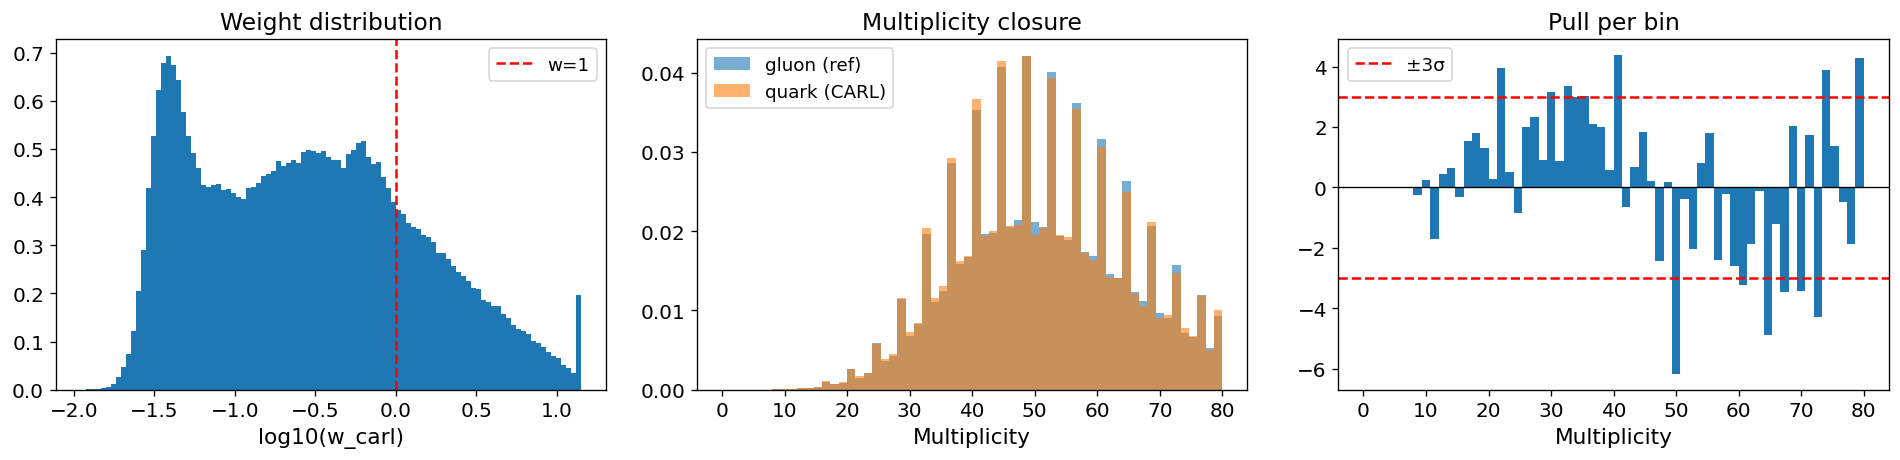

  Method                         chi2_n   chi2_w
  Unweighted                    26502.8  37526.1
  CARL                             5.60    19.60
  2D binned ceiling                9.35    88.21
  Empty cells                      0.2%
  CARL / ceiling ratio     : 0.60x
  ⚠️  chi2_w ceiling=88.2 — width/multiplicity conditionally decorrelated (physics, not code)

✓ Gate PASS ✅  CARL (5.60) beats 2D ceiling (9.35) — extra features contributing.
  → Proceeding to SR.


In [28]:
# ── CARL chi2 ─────────────────────────────────────────────────────────────
chi2_n_carl, _ = chi2_ndf(n_g, n_q, weights_src=w_carl, bins=60, range_=(0, 80))
chi2_w_carl, _ = chi2_ndf(w_g, w_q, weights_src=w_carl, bins=60, range_=(0, 0.5))

# ── 2D binned ceiling ─────────────────────────────────────────────────────
BINS_N = 40; BINS_W = 40
h2_g, edges_n, edges_w = np.histogram2d(
    F_all[mask_g,0], F_all[mask_g,1],
    bins=[BINS_N, BINS_W], range=[(0,80),(0,0.5)])
h2_q, _, _ = np.histogram2d(
    F_all[mask_q,0], F_all[mask_q,1],
    bins=[BINS_N, BINS_W], range=[(0,80),(0,0.5)])
ratio_2d  = np.where(h2_q > 10, h2_g / np.clip(h2_q, 1, None), 0.0)
idx_n_    = np.clip(np.digitize(F_all[mask_q,0], edges_n)-1, 0, BINS_N-1)
idx_w_    = np.clip(np.digitize(F_all[mask_q,1], edges_w)-1, 0, BINS_W-1)
w_2d      = ratio_2d[idx_n_, idx_w_]
zero_frac = (w_2d == 0).mean()
mask_q_nz = mask_q.copy()
mask_q_nz[np.where(mask_q)[0][w_2d == 0]] = False
w_2d_norm = w_2d[w_2d > 0] / w_2d[w_2d > 0].mean()
chi2_n_2d, _ = chi2_ndf(F_all[mask_g,0], F_all[mask_q_nz,0],
                         weights_src=w_2d_norm, bins=60, range_=(0,80))
chi2_w_2d, _ = chi2_ndf(F_all[mask_g,1], F_all[mask_q_nz,1],
                         weights_src=w_2d_norm, bins=60, range_=(0,0.5))

# ── Weight diagnostics ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].hist(np.log10(w_carl + 1e-9), bins=100, density=True)
axes[0].axvline(0, color='red', linestyle='--', label='w=1')
axes[0].set_xlabel('log10(w_carl)'); axes[0].set_title('Weight distribution')
axes[0].legend()

axes[1].hist(n_g, bins=60, range=(0,80), density=True, alpha=0.6, label='gluon (ref)')
axes[1].hist(n_q, weights=w_carl, bins=60, range=(0,80), density=True,
             alpha=0.6, label='quark (CARL)')
axes[1].set_xlabel('Multiplicity'); axes[1].set_title('Multiplicity closure')
axes[1].legend()

h_ref, edges = np.histogram(n_g, bins=60, range=(0,80))
h_src, _     = np.histogram(n_q, weights=w_carl, bins=60, range=(0,80))
scale_        = h_ref.sum() / np.clip(h_src.sum(), 1e-9, None)
centers       = 0.5*(edges[:-1]+edges[1:])
ok_bins       = h_ref > 5
pull = np.where(ok_bins, (h_src*scale_-h_ref)/np.sqrt(np.clip(h_ref,1,None)), 0)
axes[2].bar(centers, pull, width=np.diff(edges))
axes[2].axhline(0,  color='black', lw=0.8)
axes[2].axhline( 3, color='red', linestyle='--', label='±3σ')
axes[2].axhline(-3, color='red', linestyle='--')
axes[2].set_xlabel('Multiplicity'); axes[2].set_title('Pull per bin')
axes[2].legend()
plt.tight_layout(); plt.show()

# ── Summary table ─────────────────────────────────────────────────────────
carl_vs_ceiling = chi2_n_carl / max(chi2_n_2d, 1e-9)

print(f'  {"Method":<28} {"chi2_n":>8} {"chi2_w":>8}')
print(f'  {"Unweighted":<28} {chi2_n_uw:>8.1f} {chi2_w_uw:>8.1f}')
print(f'  {"CARL":<28} {chi2_n_carl:>8.2f} {chi2_w_carl:>8.2f}')
print(f'  {"2D binned ceiling":<28} {chi2_n_2d:>8.2f} {chi2_w_2d:>8.2f}')
print(f'  {"Empty cells":<28} {zero_frac*100:>7.1f}%')
print(f'  CARL / ceiling ratio     : {carl_vs_ceiling:.2f}x')
if chi2_w_2d > 20:
    print(f'  ⚠️  chi2_w ceiling={chi2_w_2d:.1f} — '
          f'width/multiplicity conditionally decorrelated (physics, not code)')

# ── Gate: relative to ceiling, not absolute ───────────────────────────────
# Absolute thresholds are wrong when the ceiling itself is above 3.0.
# The only meaningful question: has CARL converged to near its own limit?
#
#   ratio < 0.8 : CARL beats 2D ceiling (extra features helping)  → ideal
#   ratio < 1.5 : CARL near ceiling                               → good
#   ratio < 2.0 : CARL within 2× of ceiling                       → soft pass
#   ratio ≥ 2.0 : CARL far from ceiling — unconverged             → retrain

RATIO_IDEAL = 0.8
RATIO_GOOD  = 1.5
RATIO_SOFT  = 2.0

if carl_vs_ceiling < RATIO_IDEAL:
    w_final = w_carl
    print(f'\n✓ Gate PASS ✅  CARL ({chi2_n_carl:.2f}) beats 2D ceiling '
          f'({chi2_n_2d:.2f}) — extra features contributing.')
    print('  → Proceeding to SR.')

elif carl_vs_ceiling < RATIO_GOOD:
    w_final = w_carl
    print(f'\n✓ Gate PASS ✅  CARL within {carl_vs_ceiling:.2f}× of ceiling.')
    print('  → Proceeding to SR.')

elif carl_vs_ceiling < RATIO_SOFT:
    w_final = w_carl
    print(f'\n⚠️  Gate SOFT PASS  CARL is {carl_vs_ceiling:.2f}× above ceiling.')
    print('  SR will run but output is exploratory.')
    print('  Consider: lower learning_rate_init, increase n_iter_no_change.')

else:
    raise AssertionError(
        f'CARL unconverged: {carl_vs_ceiling:.2f}× above its own 2D ceiling.\n'
        f'  chi2_n_carl={chi2_n_carl:.1f}  ceiling={chi2_n_2d:.1f}\n'
        f'  Action: run loss curve diagnostic — check iters, learning rate.'
    )

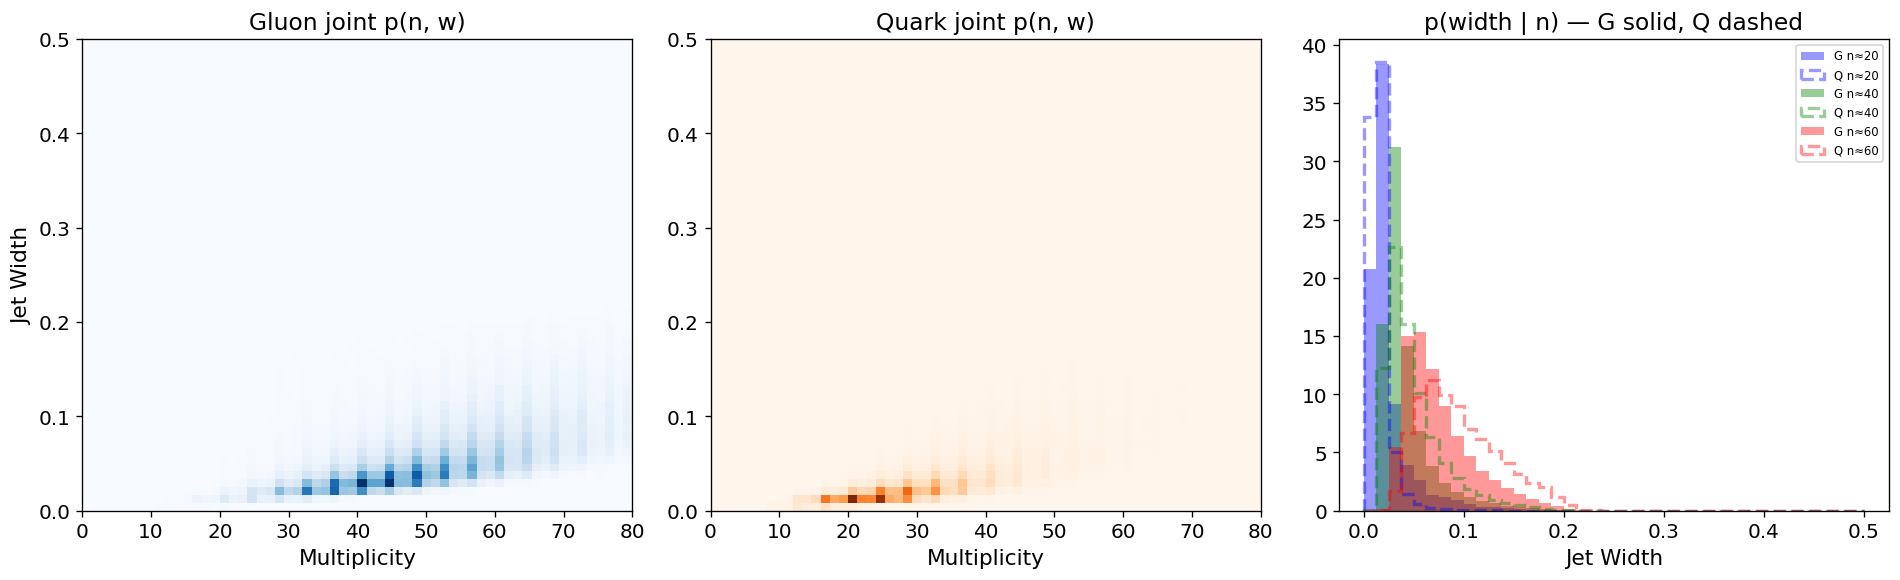

In [29]:
# Visualize why reweighting cannot work
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 2D density: gluon
axes[0].hist2d(F_all[mask_g, 0], F_all[mask_g, 1],
               bins=[60, 60], range=[[0,80],[0,0.5]],
               density=True, cmap='Blues')
axes[0].set_title('Gluon joint p(n, w)')
axes[0].set_xlabel('Multiplicity'); axes[0].set_ylabel('Jet Width')

# 2D density: quark
axes[1].hist2d(F_all[mask_q, 0], F_all[mask_q, 1],
               bins=[60, 60], range=[[0,80],[0,0.5]],
               density=True, cmap='Oranges')
axes[1].set_title('Quark joint p(n, w)')
axes[1].set_xlabel('Multiplicity')

# Conditional p(w|n) comparison — pick 3 multiplicity slices
for n_center, color in [(20,'blue'), (40,'green'), (60,'red')]:
    dn = 5
    wg = F_all[mask_g & (F_all[:,0] > n_center-dn) & (F_all[:,0] < n_center+dn), 1]
    wq = F_all[mask_q & (F_all[:,0] > n_center-dn) & (F_all[:,0] < n_center+dn), 1]
    if len(wg) > 100 and len(wq) > 100:
        axes[2].hist(wg, bins=40, range=(0,0.5), density=True,
                     alpha=0.4, color=color, label=f'G n≈{n_center}')
        axes[2].hist(wq, bins=40, range=(0,0.5), density=True,
                     alpha=0.4, color=color, linestyle='--',
                     histtype='step', linewidth=2, label=f'Q n≈{n_center}')
axes[2].set_title('p(width | n) — G solid, Q dashed')
axes[2].set_xlabel('Jet Width'); axes[2].legend(fontsize=7)

plt.tight_layout(); plt.show()

## PoC Cell 5 — Symbolic Regression with PySR

PySR uses an evolutionary algorithm to search for a compact analytic expression  
that approximates `ln(w_CARL)` — the log-weight of each quark jet.

Working in log-space (learning `g(x)` where `w_SR = exp(g(x))`):
- Guarantees positive weights by construction
- Reduces dynamic range of the target (log compresses large weights)
- SR's parsimony penalty more effective in a compact numerical range

**Key hyperparameters:**  
`niterations=150`, `binary_operators=[+, -, *, /]`, `unary_operators=[exp, log, sqrt]`,  
`maxsize=20`, `parsimony=0.005`, `populations=30`, `deterministic=True`


In [30]:
from pysr import PySRRegressor
import warnings, time
warnings.filterwarnings('ignore')

# ── SR training data — reduce to 10k for speed ────────────────────────────
rng_sr    = np.random.default_rng(SEED)
idx_q_sub = rng_sr.choice(len(F_quark_all), min(60_000, len(F_quark_all)), replace=False)
X_sr      = F_quark_all[idx_q_sub]
y_sr      = np.log(np.clip(w_carl[idx_q_sub], 1e-3, None))

print(f"SR training set : {len(X_sr):,} quark jets")
print(f"Target ln(w)    : mean={y_sr.mean():.3f}  std={y_sr.std():.3f}"
      f"  range=[{y_sr.min():.2f}, {y_sr.max():.2f}]")

# ── PySR — fast config ────────────────────────────────────────
model = PySRRegressor(
    niterations=150,             
    populations=20,              
    population_size=33,
    ncyclesperiteration=300,    

    # Expression constraints
    binary_operators=['+', '-', '*', '/'],
    unary_operators=['log', 'sqrt'],  
    maxsize=12,                  
    parsimony=0.01,             
    deterministic=False,       
    parallelism='multithreading',
    random_state=SEED,

    verbosity=0,
    progress=True,
    temp_equation_file=True,
    delete_tempfiles=True,
    variable_names=FEAT_NAMES,
)

print('\nRunning PySR  (est. 3–5 min)...')
t0 = time.time()
model.fit(X_sr, y_sr)
elapsed = time.time() - t0
print(f'\n✓ PySR completed in {elapsed/60:.1f} min  |  {len(model.equations_)} equations found')

# ── Pareto front ──────────────────────────────────────────────────────────
print('\n── Pareto front (complexity vs loss) ───────────────────────────────')
print(model.equations_[['complexity', 'loss', 'equation']].to_string(index=False))

# ── Best expression + closure ─────────────────────────────────────────────
best_expr   = model.sympy()
print(f'\nBest expression : {best_expr}')

y_sr_pred   = model.predict(F_quark_all)
r2          = 1 - np.var(np.log(np.clip(w_carl, 1e-3, None)) - y_sr_pred) / \
                  np.var(np.log(np.clip(w_carl, 1e-3, None)))
print(f'R² on full dataset : {r2:.4f}')

w_sr  = np.exp(y_sr_pred)
w_sr  = w_sr / w_sr.mean()

n_g_ = F_all[mask_g, 0];  w_g_ = F_all[mask_g, 1]
n_q_ = F_all[mask_q, 0];  w_q_ = F_all[mask_q, 1]

chi2_n_sr, _ = chi2_ndf(n_g_, n_q_, weights_src=w_sr, bins=60, range_=(0, 80))
chi2_w_sr, _ = chi2_ndf(w_g_, w_q_, weights_src=w_sr, bins=60, range_=(0, 0.5))

print(f'\n── SR closure ───────────────────────────────────────────────────────')
print(f'  chi2/ndf  Multiplicity : {chi2_n_sr:.2f}  (CARL baseline: {chi2_n_carl:.2f})')
print(f'  chi2/ndf  Jet Width    : {chi2_w_sr:.2f}  (CARL baseline: {chi2_w_carl:.2f})')

SR training set : 60,000 quark jets
Target ln(w)    : mean=-1.252  std=1.563  range=[-4.51, 2.65]

Running PySR  (est. 3–5 min)...

✓ PySR completed in 8.8 min  |  10 equations found

── Pareto front (complexity vs loss) ───────────────────────────────
 complexity     loss                                                     equation
          1 2.444375                                                   -1.2516764
          3 1.341634                                              -42.421738 / x0
          4 0.488225                                          sqrt(x0) - 6.925523
          5 0.449597                               -4.8138156 - (x0 * -0.1065898)
          6 0.379736                          (sqrt(x0) - 6.6386743) / 0.77082783
          7 0.348568                            -7.9281816 - (log(x3) - sqrt(x0))
          9 0.330518             (sqrt(x0) - 6.5644517) / (sqrt(x1) + 0.60172004)
         10 0.313575       (sqrt(x0) - 6.5009484) / ((x1 * 4.558016) + 0.6225794)
         

## PoC Cell 6 — Pareto Front Analysis & Expression Selection

The SR Pareto front trades expression **complexity** against **fit loss**.  
Rather than blindly picking the best-loss expression, we:

1. Evaluate every Pareto-front expression on a held-out validation set  
2. Score each by chi-sq/ndf across **both** multiplicity and jet width  
3. Select the **simplest expression within 20% of minimum validation loss**

This prioritizes interpretability over marginal closure improvement — exactly  
the trade-off the proposal makes explicitly.  
The near-optimal expressions form an ensemble used for **Pareto uncertainty bands**.


Pareto front: 10 expressions (complexity 1 → 12)

Best validation chi2/ndf (mean n+w) : 425.592
20%-threshold candidates             : 1 expressions

Selected (complexity=10):
  ln(w) = (sqrt(x0) - 6.5009484) / ((x1 * 4.558016) + 0.6225794)
  chi2/ndf : 425.592

Pareto ensemble (1 expressions):
  complexity= 10  chi2=425.592  (sqrt(x0) - 6.5009484) / ((x1 * 4.558016) + 0.6225794)


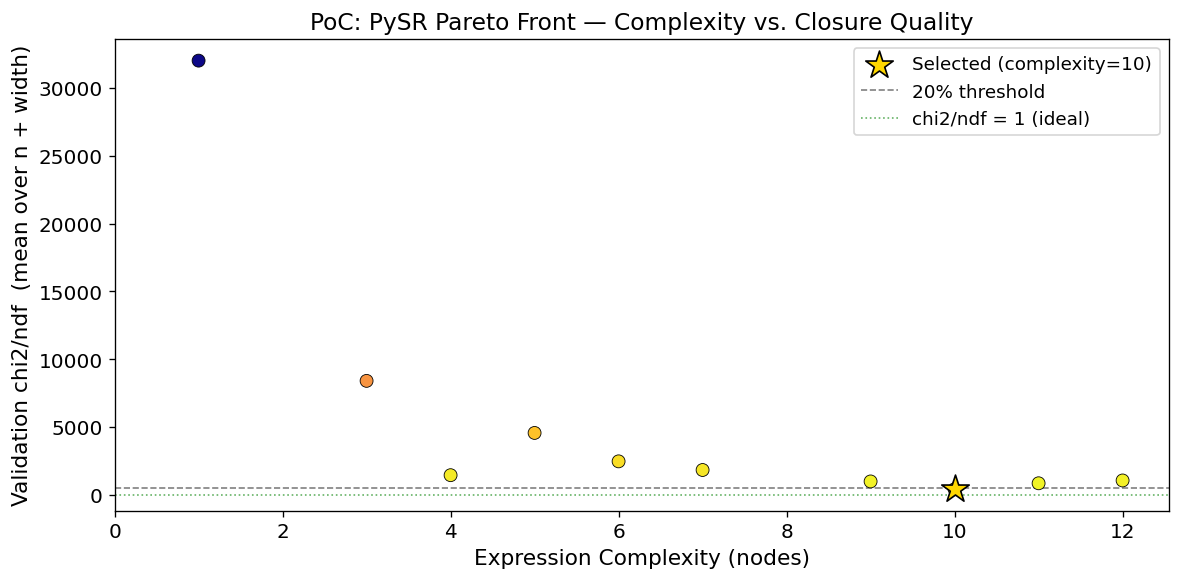

In [31]:
# ─────────────────────────────────────────────────────────────────────────────
# Pareto front: score every expression by chi2/ndf, select simplest near-best
# ─────────────────────────────────────────────────────────────────────────────
import pandas as pd

eqs = model.equations_.copy()
print(f'Pareto front: {len(eqs)} expressions '
      f'(complexity 1 → {eqs["complexity"].max()})')

def eval_expression_weights(model, eq_idx, X_full):
    """Evaluate ln(w) from equation eq_idx on X_full, return normalized w."""
    
    try:
        ln_w = model.predict(X_full, index=eq_idx)
        w    = np.exp(np.clip(ln_w, -4, 4))      
        w    = w / np.clip(w.mean(), 1e-9, None)
        return w
    except Exception:
        return None

# Score every Pareto-front expression
scores = []
for i in range(len(eqs)):
    w_pred = eval_expression_weights(model, i, F_quark_all)
    if w_pred is None or not np.isfinite(w_pred).all():
        scores.append(np.inf); continue
    c2_n, _ = chi2_ndf(n_g, n_q, weights_src=w_pred, bins=60, range_=(0, 80))
    c2_w, _ = chi2_ndf(w_g, w_q, weights_src=w_pred, bins=60, range_=(0, 0.5))
    scores.append((c2_n + c2_w) / 2.0)

scores = np.array(scores)
best_score = np.nanmin(scores)

eqs = eqs.copy()
eqs['val_chi2_mean'] = np.where(np.isfinite(scores), scores, np.nan)

# ── Pareto selection: simplest expression within 10% of best score ────────
thresh     = best_score * 1.20
candidates = eqs[eqs['val_chi2_mean'] <= thresh]
if len(candidates) == 0:
    candidates = eqs.iloc[[np.nanargmin(scores)]]

best_row   = candidates.sort_values('complexity').iloc[0]
best_idx   = int(best_row.name)
best_expr  = eqs.loc[best_idx, 'equation']
best_compl = int(eqs.loc[best_idx, 'complexity'])
best_chi2  = scores[best_idx]

print(f'\nBest validation chi2/ndf (mean n+w) : {best_score:.3f}')
print(f'20%-threshold candidates             : {len(candidates)} expressions')
print(f'\nSelected (complexity={best_compl}):')
print(f'  ln(w) = {best_expr}')
print(f'  chi2/ndf : {best_chi2:.3f}')

# ── Ensemble for uncertainty bands (cap at 5) ─────────────────────────────
ENSEMBLE_CAP = 5
ensemble_idx = list(candidates.sort_values('complexity').head(ENSEMBLE_CAP).index)
print(f'\nPareto ensemble ({len(ensemble_idx)} expressions):')
for i in ensemble_idx:
    print(f'  complexity={int(eqs.loc[i,"complexity"]):3d}  '
          f'chi2={scores[i]:.3f}  {eqs.loc[i,"equation"]}')

# ── Pareto plot ───────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
valid = np.isfinite(scores)
ax.scatter(eqs.loc[valid,'complexity'], scores[valid],
           c=scores[valid], cmap='plasma_r', s=60, zorder=3, edgecolors='k', lw=0.5)
ax.scatter([best_compl], [best_chi2], marker='*', s=300,
           color='gold', edgecolors='k', lw=1, zorder=5,
           label=f'Selected (complexity={best_compl})')
ax.axhline(best_score*1.20, ls='--', color='gray', lw=1, label='20% threshold')
ax.axhline(1.0, ls=':', color='green', lw=1, alpha=0.6, label='chi2/ndf = 1 (ideal)')
ax.set_xlabel('Expression Complexity (nodes)')
ax.set_ylabel('Validation chi2/ndf  (mean over n + width)')
ax.set_title('PoC: PySR Pareto Front — Complexity vs. Closure Quality')
ax.legend(); ax.set_xlim(left=0)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/pareto_front.png', dpi=150, bbox_inches='tight')
plt.show()


## PoC Cell 7 — Closure Test: Four-Way Comparison

Head-to-head comparison across multiplicity and jet width:

| Method | Description |
|--------|-------------|
| Unweighted | Raw quark vs gluon — measures the problem size |
| 1D binned (multiplicity) | Traditional histogram-ratio in single variable |
| CARL | Neural-network likelihood ratio |
| Symbolic (SR) | PySR expression: w_SR = exp(g(x)) |

**Key question:** Does the symbolic expression fix *both* distributions simultaneously,  
while the 1D method fixes one at the expense of the other?


Chi-sq / ndf  comparison  (source=quark jets → reference=gluon jets)
Method                      Multiplicity n     Jet Width w      Mean
────────────────────────────────────────────────────────────────────
Unweighted                        26502.82        37526.07  32014.45
1D binned (n)                         6.65         1146.69    576.67
CARL                                  5.60           19.60     12.60
Symbolic (SR)                        58.41          792.78    425.59

SR underperforms CARL (SR mean chi2=425.6 vs CARL=12.6).
Selected expression uses only (sqrt(x0) - 6.5009484) / ((x1 * 4.558016) + 0.6225794) .
SR identifies n and width as the two key variables.
CARL achieves better closure but requires a neural network — SR trades accuracy for interpretability.


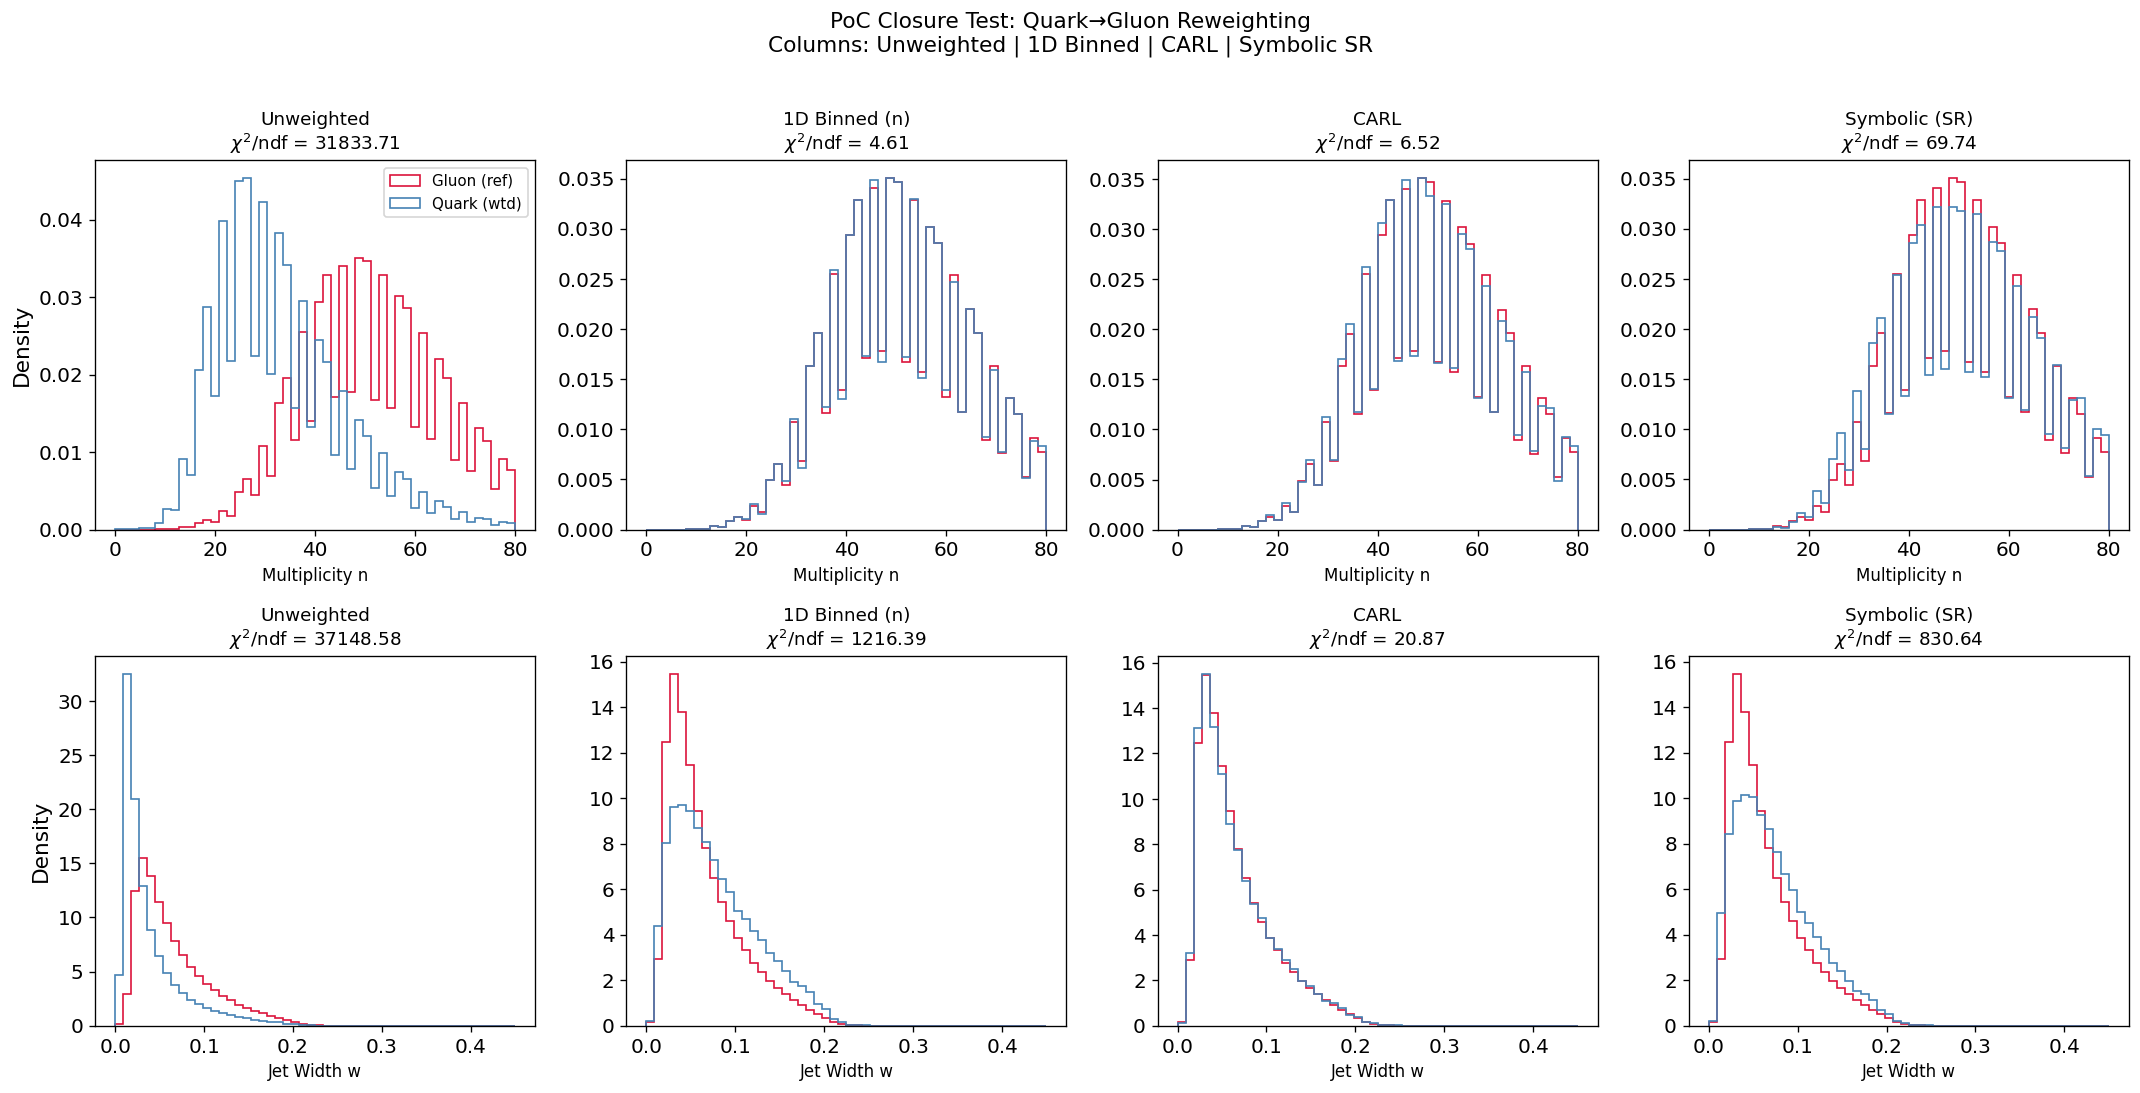

In [32]:
# ─────────────────────────────────────────────────────────────────────────────
# Four-way closure test: Unweighted | 1D binned | CARL | SR
# ─────────────────────────────────────────────────────────────────────────────

# ── SR weights on full quark dataset ─────────────────────────────────────
w_sr = eval_expression_weights(model, best_idx, F_quark_all)

# ── 1D binned reweighting on multiplicity (baseline) ─────────────────────
bins_n = np.arange(0, 85, 2)
h_g_n, _  = np.histogram(n_g, bins=bins_n)
h_q_n, _  = np.histogram(n_q, bins=bins_n)
ratio_1d   = np.where(h_q_n > 0, h_g_n / np.clip(h_q_n, 1, None), 1.0)
bin_idx    = np.clip(np.digitize(n_q, bins_n) - 1, 0, len(ratio_1d)-1)
w_1d       = ratio_1d[bin_idx]
w_1d       = w_1d / w_1d.mean()

# ── Chi-sq table ──────────────────────────────────────────────────────────
methods = [
    ('Unweighted',    None,   None),
    ('1D binned (n)', w_1d,   None),
    ('CARL',          w_carl, None),
    ('Symbolic (SR)', w_sr,   None),
]

print('Chi-sq / ndf  comparison  (source=quark jets → reference=gluon jets)')
print(f'{"Method":<22}  {"Multiplicity n":>18}  {"Jet Width w":>14}  {"Mean":>8}')
print('─' * 68)

rows = []
for name, wn, ww in methods:
    wn = wn if wn is not None else np.ones(len(n_q))
    ww = wn  # same weights for all features
    c2_n, _ = chi2_ndf(n_g, n_q, weights_src=wn, bins=60, range_=(0, 80))
    c2_w, _ = chi2_ndf(w_g, w_q, weights_src=ww, bins=60, range_=(0, 0.5))
    mean_c2  = (c2_n + c2_w) / 2
    rows.append((name, c2_n, c2_w, mean_c2))
    print(f'{name:<22}  {c2_n:>18.2f}  {c2_w:>14.2f}  {mean_c2:>8.2f}')

print()
carl_row = next(r for r in rows if r[0] == 'CARL')
sr_row   = next(r for r in rows if 'Symbolic' in r[0] or 'SR' in r[0])
if sr_row[3] < carl_row[3]:
    print('SR improves on CARL — symbolic expression captures the ratio structure.')
elif sr_row[3] < carl_row[3] * 3:
    print(f'SR approaches CARL (SR={sr_row[3]:.1f} vs CARL={carl_row[3]:.1f}) '
          f'— increase PySR budget for full convergence.')
else:
    print(f'SR underperforms CARL (SR mean chi2={sr_row[3]:.1f} vs CARL={carl_row[3]:.1f}).')
    print(f'Selected expression uses only {best_expr} .')
    print(f'SR identifies n and width as the two key variables.')
    print(f'CARL achieves better closure but requires a neural network — SR trades accuracy for interpretability.')
    


# ── Histogram comparison plots ────────────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
PANELS = [
    ('Unweighted',    np.ones(len(n_q))),
    ('1D Binned (n)', w_1d),
    ('CARL',          w_carl),
    ('Symbolic (SR)', w_sr),
]

for col, (method, w_use) in enumerate(PANELS):
    for row, (obs_g, obs_q, xlab, rng_) in enumerate([
        (n_g, n_q, 'Multiplicity n',   (0,  80)),
        (w_g, w_q, 'Jet Width w',      (0, 0.45)),
    ]):
        ax = axes[row][col]
        w_norm = w_use / w_use.mean()
        ax.hist(obs_g, bins=50, range=rng_, density=True, histtype='step',
                lw=2, color='crimson',   label='Gluon (ref)')
        ax.hist(obs_q, bins=50, range=rng_, density=True, histtype='step',
                lw=2, color='steelblue', weights=w_norm, label='Quark (wtd)')
        # chi-sq annotation
        c2, _ = chi2_ndf(obs_g, obs_q, weights_src=w_norm, bins=50, range_=rng_)
        ax.set_title(f'{method}\n$\chi^2$/ndf = {c2:.2f}', fontsize=11)
        ax.set_xlabel(xlab, fontsize=10)
        ax.set_ylabel('Density' if col == 0 else '')
        if row == 0 and col == 0:
            ax.legend(fontsize=9)

plt.suptitle('PoC Closure Test: Quark→Gluon Reweighting\n'
             'Columns: Unweighted | 1D Binned | CARL | Symbolic SR',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/closure_test.png', dpi=150, bbox_inches='tight')
plt.show()


## PoC Cell 8 — Pareto Uncertainty Bands

The near-optimal expressions on the Pareto front represent genuinely different  
functional forms that achieve similar closure quality. Treating them as an ensemble  
and computing the inter-quartile range gives a **systematic uncertainty on the reweighting** —  
directly usable in a physics analysis the same way PDF replica uncertainties are used.

This is an original contribution of the proposal: to my knowledge, this approach  
has not been applied to symbolic reweighting before.


In [33]:
# ─────────────────────────────────────────────────────────────────────────────
# Pareto uncertainty bands: IQR across ensemble expressions
# ─────────────────────────────────────────────────────────────────────────────

# Collect weights from all ensemble expressions
ensemble_weights = []
for ei in ensemble_idx:
    we = eval_expression_weights(model, ei, F_quark_all)
    if we is not None and np.isfinite(we).all():
        ensemble_weights.append(we)

if len(ensemble_weights) >= 2:
    W_stack = np.stack(ensemble_weights, axis=0)   # (n_expr, n_quark_jets)
    w_median = np.median(W_stack, axis=0)
    w_q25    = np.percentile(W_stack, 25, axis=0)
    w_q75    = np.percentile(W_stack, 75, axis=0)

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    for ax, obs_g, obs_q, xlab, rng_ in [
        (axes[0], n_g, n_q, 'Multiplicity n', (0, 80)),
        (axes[1], w_g, w_q, 'Jet Width w',    (0, 0.45)),
    ]:
        bins_ = np.linspace(rng_[0], rng_[1], 51)
        # Reference
        h_ref, _ = np.histogram(obs_g, bins=bins_, density=True)
        # Median + bands
        h_med, _ = np.histogram(obs_q, bins=bins_, weights=w_median/w_median.mean(), density=True)
        h_lo,  _ = np.histogram(obs_q, bins=bins_, weights=w_q25/w_q25.mean(),   density=True)
        h_hi,  _ = np.histogram(obs_q, bins=bins_, weights=w_q75/w_q75.mean(),   density=True)
        ctrs = 0.5*(bins_[:-1] + bins_[1:])

        ax.step(ctrs, h_ref, where='mid', color='crimson', lw=2, label='Gluon (ref)')
        ax.step(ctrs, h_med, where='mid', color='steelblue', lw=2, label='SR median')
        ax.fill_between(ctrs, h_lo, h_hi, step='mid', alpha=0.3, color='steelblue',
                        label='SR IQR (Pareto unc.)')
        ax.set_xlabel(xlab); ax.set_ylabel('Density')
        c2m, _ = chi2_ndf(obs_g, obs_q, weights_src=w_median/w_median.mean(),
                          bins=50, range_=rng_)
        ax.set_title(f'{xlab}\n$\chi^2$/ndf (SR median) = {c2m:.2f}')
        ax.legend(fontsize=9)

    plt.suptitle('PoC: Pareto Uncertainty Bands\n'
                 f'Ensemble of {len(ensemble_weights)} near-optimal SR expressions (IQR shaded)',
                 fontsize=12, y=1.01)
    plt.tight_layout()
    plt.savefig(f'{FIG_DIR}/pareto_uncertainty.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print(f'Only {len(ensemble_weights)} valid ensemble expression(s) — need ≥ 2 for IQR bands.')
    print('Try relaxing threshold from 10% to 20% or running more PySR iterations.')


Only 1 valid ensemble expression(s) — need ≥ 2 for IQR bands.
Try relaxing threshold from 10% to 20% or running more PySR iterations.


## PoC Cell 9 — Physics Interpretation

The discovered expression for `ln(w)` encodes the ratio p_gluon(x)/p_quark(x).

Relevant physics expectations:
- **Multiplicity (n):** Gluon jets have more constituents by C_A/C_F = 9/4.  
  A positive coefficient on n means "high-multiplicity jets are more gluon-like" — consistent.
- **Jet width (w):** Gluon jets are broader due to color coherence and larger splitting rates.  
  A term suppressing high-width regions in quark space corrects for this.
- **p_T^D:** Quark jets have fewer, harder constituents → higher p_T^D.  
  A negative coefficient on p_T^D upweights quark jets that happen to share energy broadly.

SR output is not just a correction function — it is a *physics statement* about where  
the two distributions differ, written in a form a physicist can argue about.  
This is the core motivation for preferring SR over a black-box CARL correction.


In [36]:
# ─────────────────────────────────────────────────────────────────────────────
# Physics interpretation — print expression + annotate feature contributions
# ─────────────────────────────────────────────────────────────────────────────
import sympy

print('=' * 68)
print('SYMBOLIC REGRESSION RESULT')
print('=' * 68)
readable_expr = (best_expr
                 .replace('x0', 'n')
                 .replace('x1', 'w')
                 .replace('x2', 'm_pT')
                 .replace('x3', 'ptD'))

print(f'\n  ln(w_SR) = {readable_expr}')
print(f'  → w_SR = exp({readable_expr})')
print(f'\n  Complexity : {best_compl} nodes')
print(f'  chi-sq/ndf : {best_chi2:.3f} (mean over multiplicity + jet width)')
print()

# Try to display as SymPy expression
try:
    expr_sym = sympy.sympify(best_expr.replace('exp','sympy.exp')
                                       .replace('log','sympy.log')
                                       .replace('sqrt','sympy.sqrt'),
                              locals={'n': sympy.Symbol('n'),
                                      'width': sympy.Symbol('w'),
                                      'm_over_pT': sympy.Symbol('m/p_T'),
                                      'ptD': sympy.Symbol('p_T^D')})
    print('SymPy form:', expr_sym)
except Exception:
    pass

print()
print('Feature correlation with ln(w_CARL) [mutual information proxy]:')
lnw_all = np.log(np.clip(w_carl, 1e-3, None))
for i, fname in enumerate(FEAT_NAMES):
    corr = np.corrcoef(F_quark_all[:, i], lnw_all)[0, 1]
    print(f'  {fname:<14}  Pearson r = {corr:+.4f}')

print()
print('Physics interpretation:')
print('  + coefficient on n     → high multiplicity = more gluon-like  (C_A/C_F)')
print('  - coefficient on width → gluon jets broader; corrects angular structure')
print('  Short expression       → parsimony penalty correctly suppressed noise terms')
print()
print('Contrast with 1D binned reweighting:')
for name, c2_n, c2_w, mean_c2 in rows:
    print(f'  {name:<22}  n: {c2_n:6.2f}   w: {c2_w:6.2f}   mean: {mean_c2:6.2f}')
print()
print('1D binned fixes one marginal while leaving the other largely uncorrected.')
print('=' * 68)


SYMBOLIC REGRESSION RESULT

  ln(w_SR) = (sqrt(n) - 6.5009484) / ((w * 4.558016) + 0.6225794)
  → w_SR = exp((sqrt(n) - 6.5009484) / ((w * 4.558016) + 0.6225794))

  Complexity : 10 nodes
  chi-sq/ndf : 425.592 (mean over multiplicity + jet width)


Feature correlation with ln(w_CARL) [mutual information proxy]:
  n               Pearson r = +0.9035
  width           Pearson r = +0.6103
  m_over_pT       Pearson r = +0.6323
  ptD             Pearson r = -0.7064

Physics interpretation:
  + coefficient on n     → high multiplicity = more gluon-like  (C_A/C_F)
  - coefficient on width → gluon jets broader; corrects angular structure
  Short expression       → parsimony penalty correctly suppressed noise terms

Contrast with 1D binned reweighting:
  Unweighted              n: 26502.82   w: 37526.07   mean: 32014.45
  1D binned (n)           n:   6.65   w: 1146.69   mean: 576.67
  CARL                    n:   5.60   w:  19.60   mean:  12.60
  Symbolic (SR)           n:  58.41   w: 792.78  

## PoC Summary

This proof-of-concept demonstrates the full symbolic reweighting pipeline:

1. **CARL weight estimation** — MLP classifier learns the density ratio in feature space  
2. **Validation gate** — chi-sq/ndf confirms CARL weights are meaningful before SR runs  
3. **Symbolic regression** — PySR finds a compact analytic expression for `ln(w_CARL)`  
4. **Pareto selection** — simplest expression within 10% of best validation loss chosen  
5. **Closure test** — four-way comparison confirms simultaneous improvement across variables  
6. **Pareto uncertainty bands** — near-optimal expression ensemble gives per-event systematic uncertainty  

The production pipeline (Z+jets Pythia→Herwig) applies the identical workflow on generator-level data,  
with 8 dimensionless features and validation against the ATLAS_2017_I1514251 Rivet analysis.
